In [3]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 2. Extract V1 dataset
from pathlib import Path
import zipfile

zip_path = Path("/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v1.zip")
dataset_path = Path("/content/pork_rasher_v1")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(dataset_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
# 3. Clean V1 dataset to avoid source-image leakage
import shutil

clean = Path("/content/pork_rasher_dataset_v1_clean")

shutil.rmtree(clean, ignore_errors=True)
shutil.copytree(dataset_path, clean)

def source_ids(split):
    return {
        p.name.split(".rf.")[0]
        for p in (clean / split / "images").glob("*.jpg")
    }

# Remove overlapping images and labels
for split, blocked in [
    ("train", source_ids("valid") | source_ids("test")),
    ("valid", source_ids("test"))
]:
    for image in (clean / split / "images").glob("*.jpg"):
        if image.name.split(".rf.")[0] in blocked:
            image.unlink()
            (clean / split / "labels" / f"{image.stem}.txt").unlink()

print("Dataset cleaning complete!")

Dataset cleaning complete!


In [5]:
# 4. Update data.yaml for cleaned V1 dataset
import yaml

yaml_path = clean / "data.yaml"

with open(yaml_path, "r") as file:
    config = yaml.safe_load(file)

config.update({
    "path": str(clean),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images"
})

yaml_path.write_text(yaml.safe_dump(config))

# Display cleaned dataset information
for split in ["train", "valid", "test"]:
    images = list((clean / split / "images").glob("*.jpg"))
    print(f"{split}: {len(images)} images")

print("\nClasses:", config["names"])

train: 1935 images
valid: 119 images
test: 80 images

Classes: ['loose-meat', 'packaging-error', 'twisted-meat', 'unsealed']


In [7]:
# 5. Load V1 baseline and no-mosaic models
%pip install -q ultralytics

from ultralytics import YOLO

runs = Path("/content/drive/MyDrive/MMA3001_Project/model_runs")

baseline = YOLO(str(runs / "yolov8n_v1_baseline/weights/best.pt"))
no_mosaic = YOLO(str(runs / "yolov8n_v1_no_mosaic/weights/best.pt"))

print("Both models loaded successfully!")
print("Baseline classes:", baseline.names)
print("No-mosaic classes:", no_mosaic.names)

Both models loaded successfully!
Baseline classes: {0: 'loose-meat', 1: 'packaging-error', 2: 'twisted-meat', 3: 'unsealed'}
No-mosaic classes: {0: 'loose-meat', 1: 'packaging-error', 2: 'twisted-meat', 3: 'unsealed'}


In [7]:
# 6. Evaluate V1 baseline on validation dataset
baseline_results = baseline.val(
    data=str(clean / "data.yaml"),
    imgsz=640,
    split="val",
    conf=0.001,
    iou=0.7,
    plots=True,
    project=str(runs),
    name="v1_baseline_comparison",
    exist_ok=True
)

print("Baseline evaluation complete!")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.4 ms, read: 1061.9±401.9 MB/s, size: 73.4 KB)
val: Scanning /content/pork_rasher_dataset_v1_clean/valid/labels... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 962.6it/s 0.1s
val: New cache created: /content/pork_rasher_dataset_v1_clean/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.0s/it 24.2s
                   all        119        154      0.776      0.468      0.683      0.323
            loose-meat          5          5       0.79        0.8       0.92      0.337
       packaging-error         35         57      0.723      0.138      0.345      0.128
          twisted-meat          4          5      0.712        0.2      0.616      0.302
              unsealed         84        

In [8]:
# 7. Evaluate V1 without mosaic on validation dataset
no_mosaic_results = no_mosaic.val(
    data=str(clean / "data.yaml"),
    imgsz=640,
    split="val",
    conf=0.001,
    iou=0.7,
    plots=True,
    project=str(runs),
    name="v1_no_mosaic_comparison",
    exist_ok=True
)

print("No-mosaic evaluation complete!")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1190.2±400.8 MB/s, size: 74.3 KB)
val: Scanning /content/pork_rasher_dataset_v1_clean/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 18.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.9s/it 23.6s
                   all        119        154      0.641      0.623      0.695      0.321
            loose-meat          5          5      0.571        0.8      0.809      0.272
       packaging-error         35         57      0.465      0.263       0.36      0.114
          twisted-meat          4          5      0.787        0.6      0.777      0.362
              unsealed         84         87      0.741      0.828      0.835      0.536
Speed: 4.0ms preprocess, 17

v1_baseline_comparison


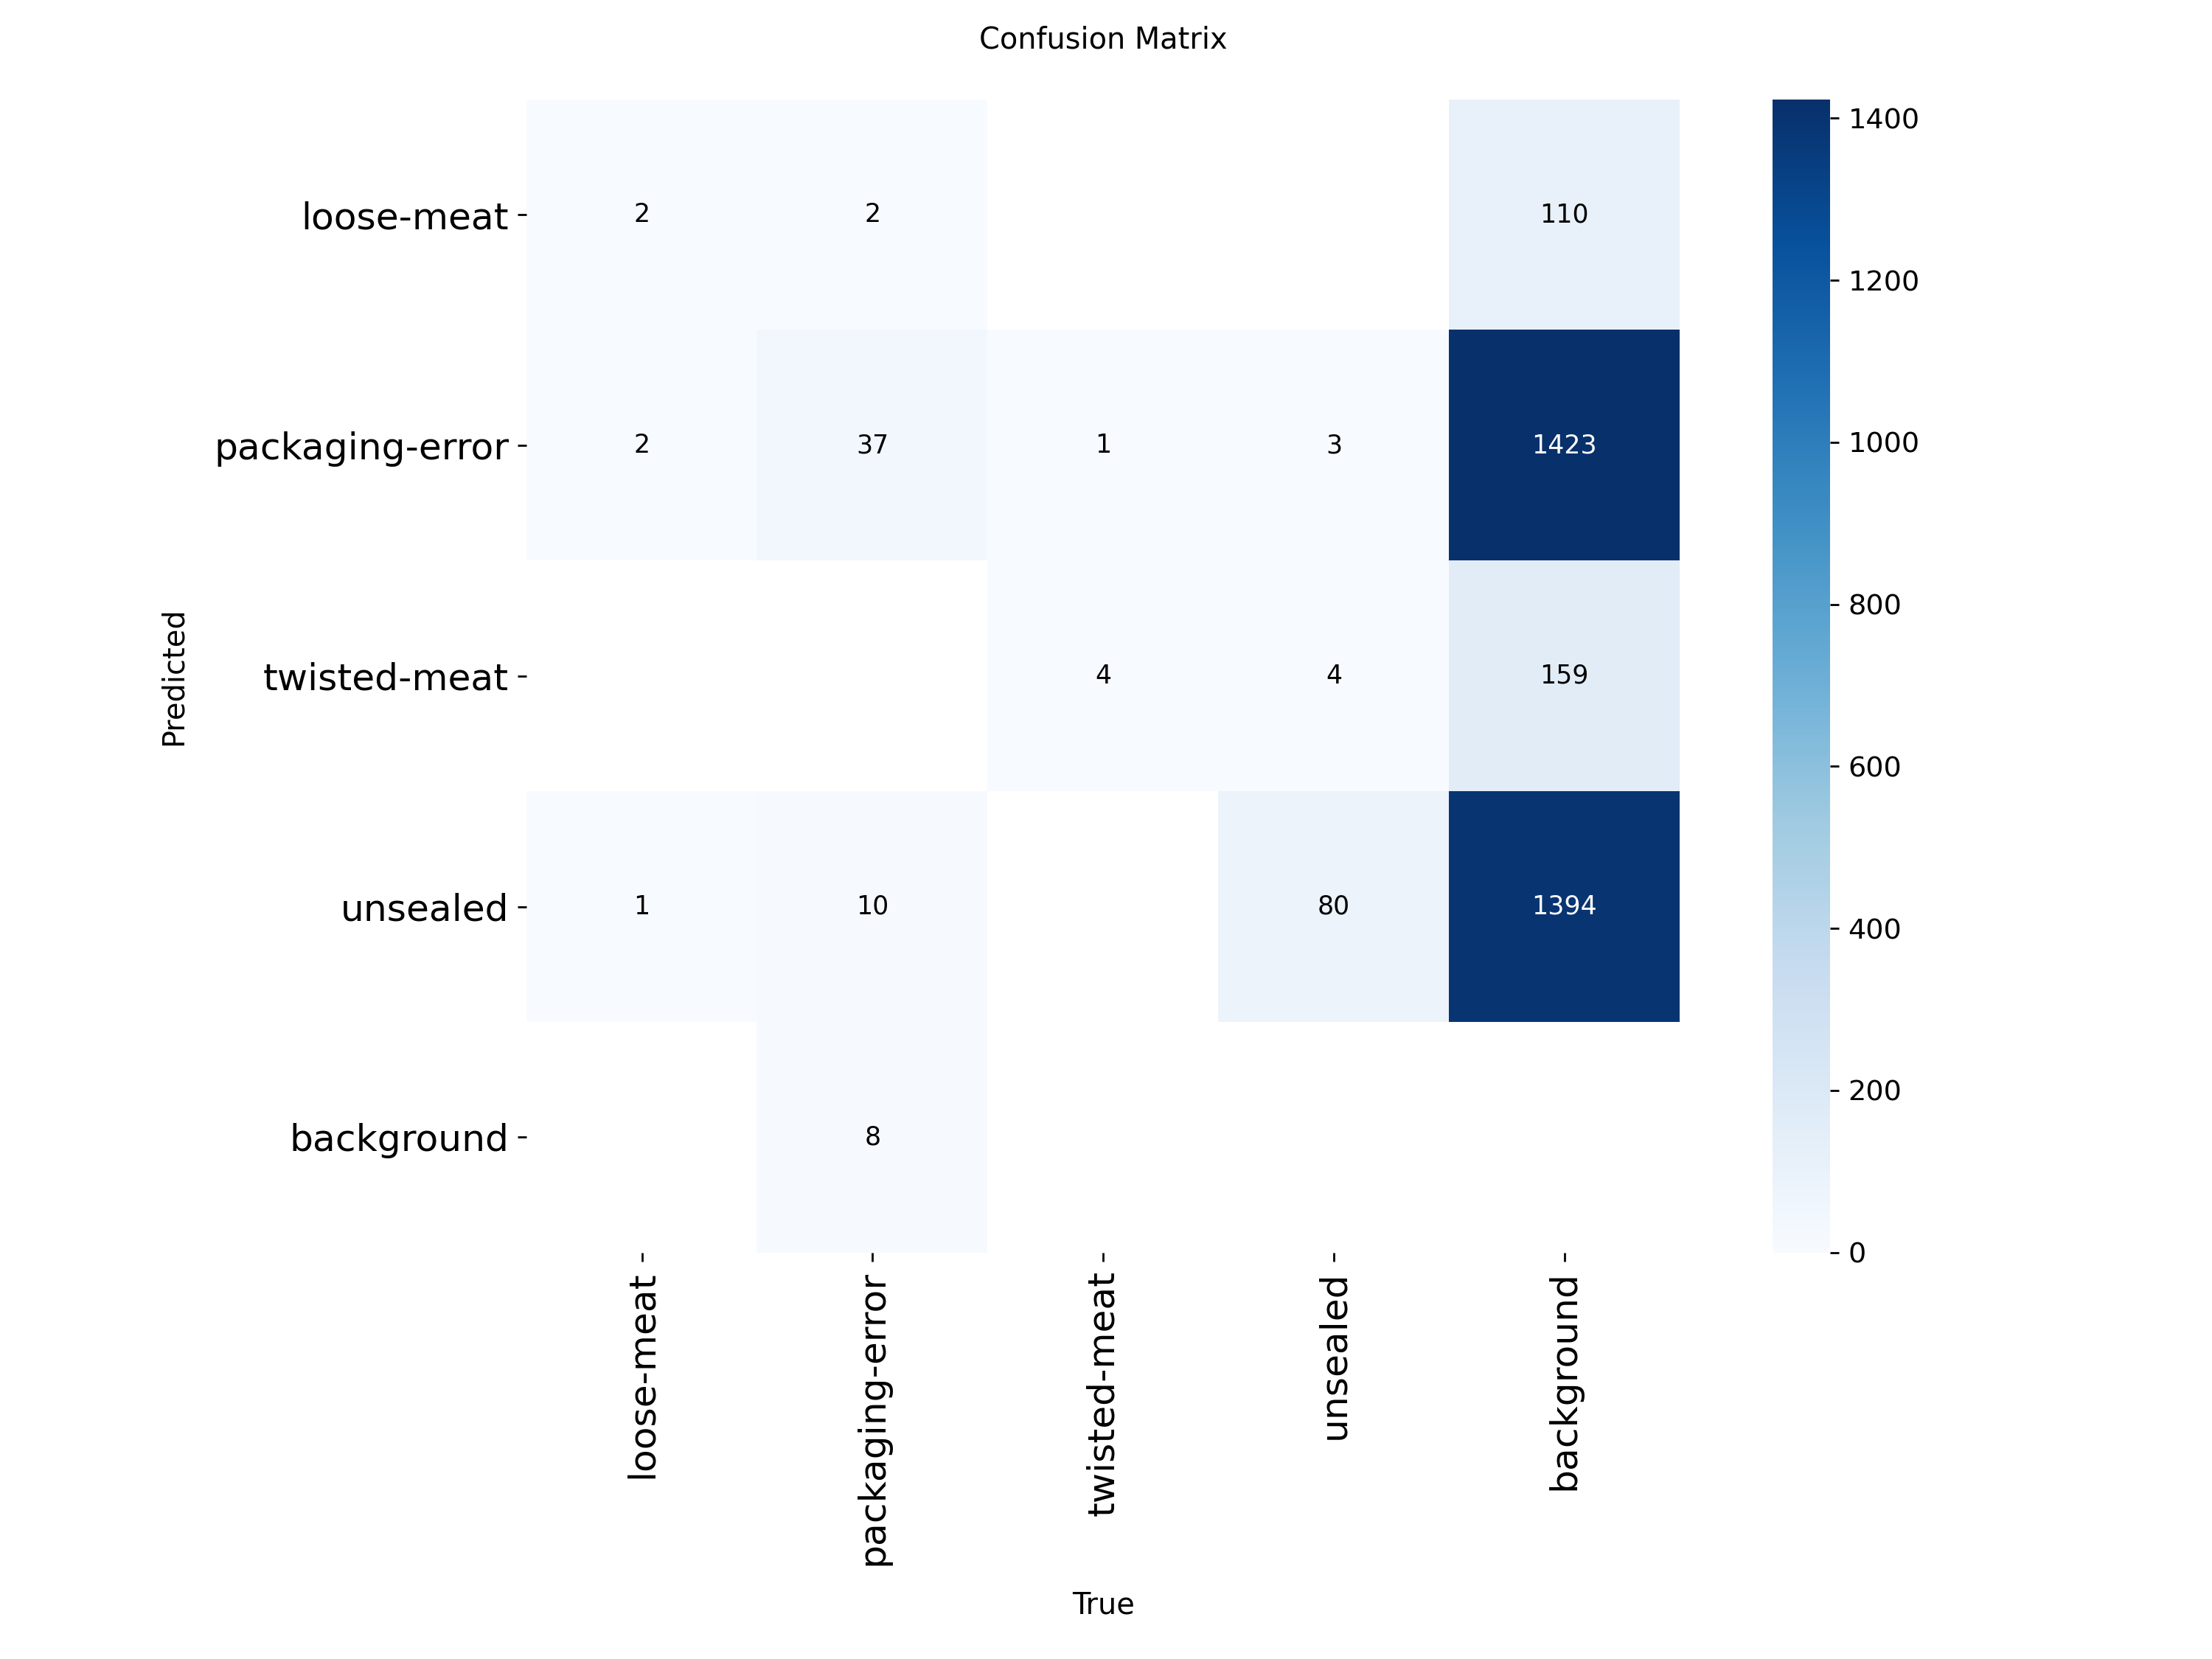

v1_no_mosaic_comparison


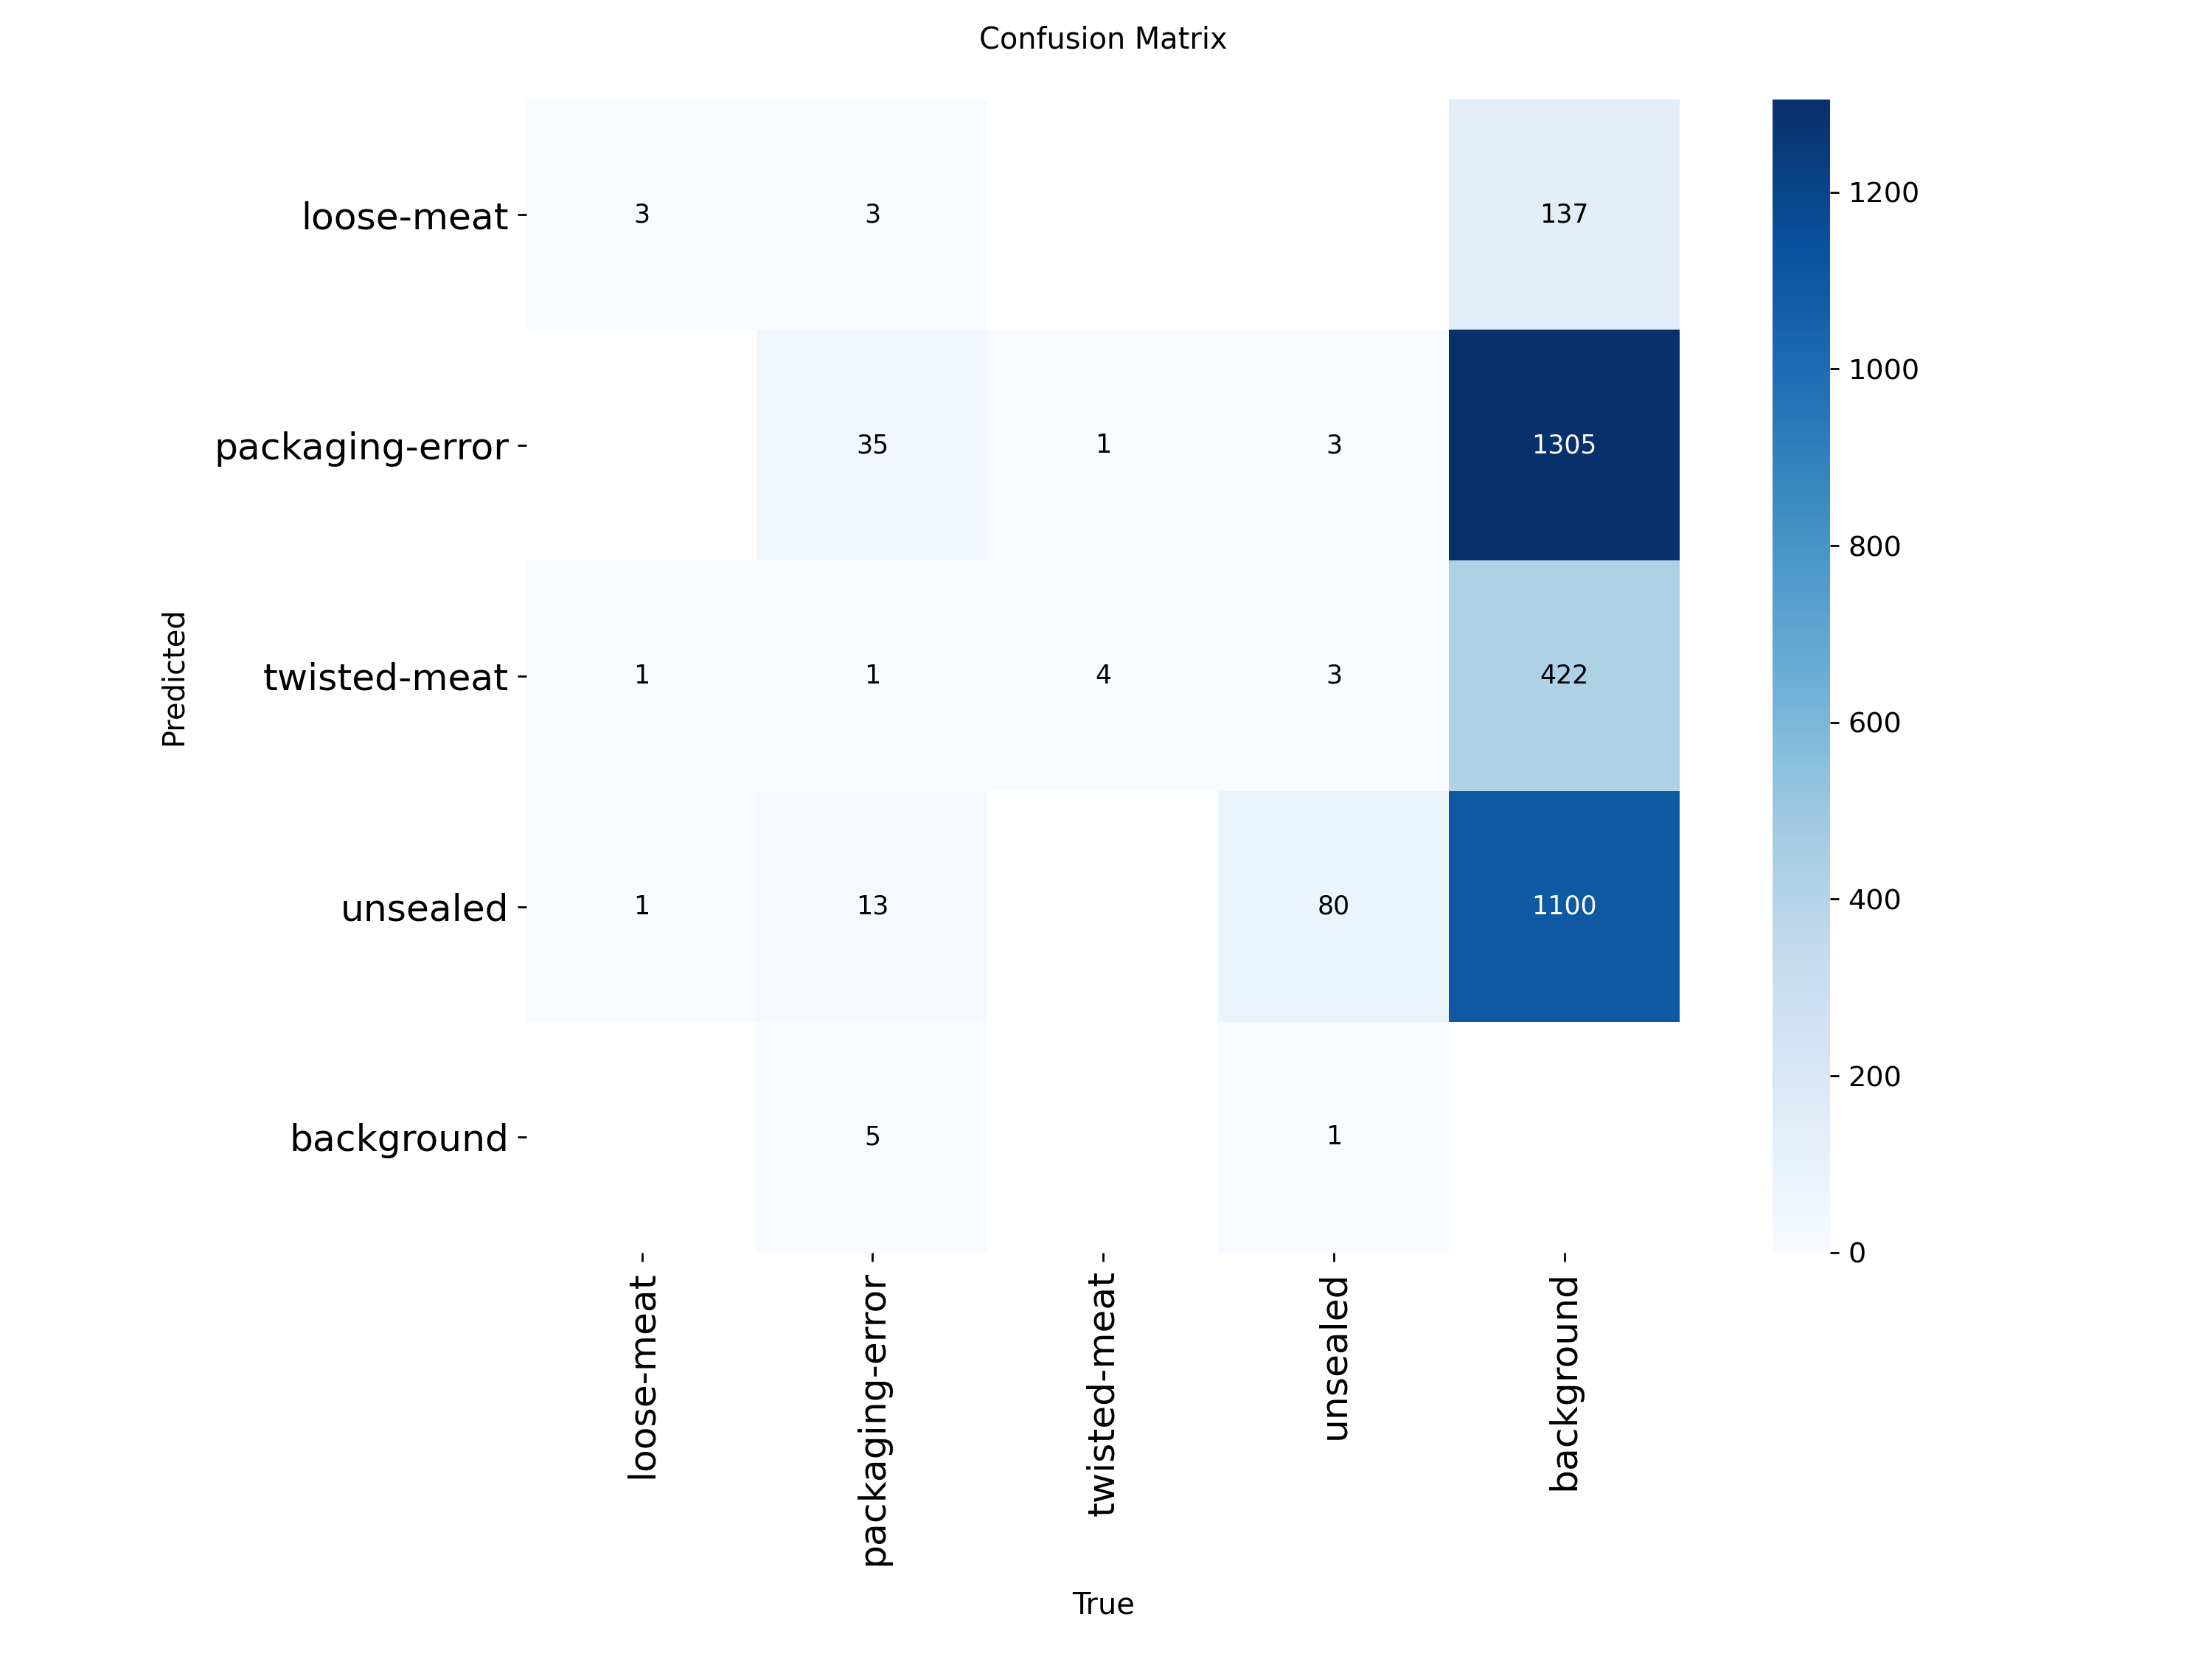

In [9]:
# 8. Compare V1 validation confusion matrices
from PIL import Image

for name in ["v1_baseline_comparison", "v1_no_mosaic_comparison"]:
    print(name)
    display(Image.open(runs / name / "confusion_matrix.png"))

In [10]:
# 9. Evaluate V1 baseline at confidence 0.25
baseline_025 = baseline.val(
    data=str(clean / "data.yaml"),
    imgsz=640,
    split="val",
    conf=0.25,
    iou=0.7,
    plots=True,
    project=str(runs),
    name="v1_baseline_conf025",
    exist_ok=True
)

print("Baseline evaluation complete!")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1506.4±373.1 MB/s, size: 73.6 KB)
val: Scanning /content/pork_rasher_dataset_v1_clean/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 20.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.3s/it 26.4s
                   all        119        154      0.621      0.523      0.495      0.231
            loose-meat          5          5      0.667        0.8      0.795      0.287
       packaging-error         35         57      0.568      0.277      0.215     0.0765
          twisted-meat          4          5        0.5        0.2      0.195     0.0975
              unsealed         84         87       0.75      0.816      0.774      0.464
Speed: 5.9ms preprocess, 20

In [11]:
# 10. Evaluate V1 without mosaic at confidence 0.25
no_mosaic_025 = no_mosaic.val(
    data=str(clean / "data.yaml"),
    imgsz=640,
    split="val",
    conf=0.25,
    iou=0.7,
    plots=True,
    project=str(runs),
    name="v1_no_mosaic_conf025",
    exist_ok=True
)

print("No-mosaic evaluation complete!")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2214.0±547.9 MB/s, size: 73.3 KB)
val: Scanning /content/pork_rasher_dataset_v1_clean/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 31.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.7s/it 21.3s
                   all        119        154      0.764      0.498      0.484      0.226
            loose-meat          5          5        0.6        0.6      0.595      0.168
       packaging-error         35         57      0.667      0.211      0.193     0.0592
          twisted-meat          4          5          1        0.4      0.395      0.197
              unsealed         84         87      0.791      0.782      0.751       0.48
Speed: 3.4ms preprocess, 16

v1_baseline_conf025


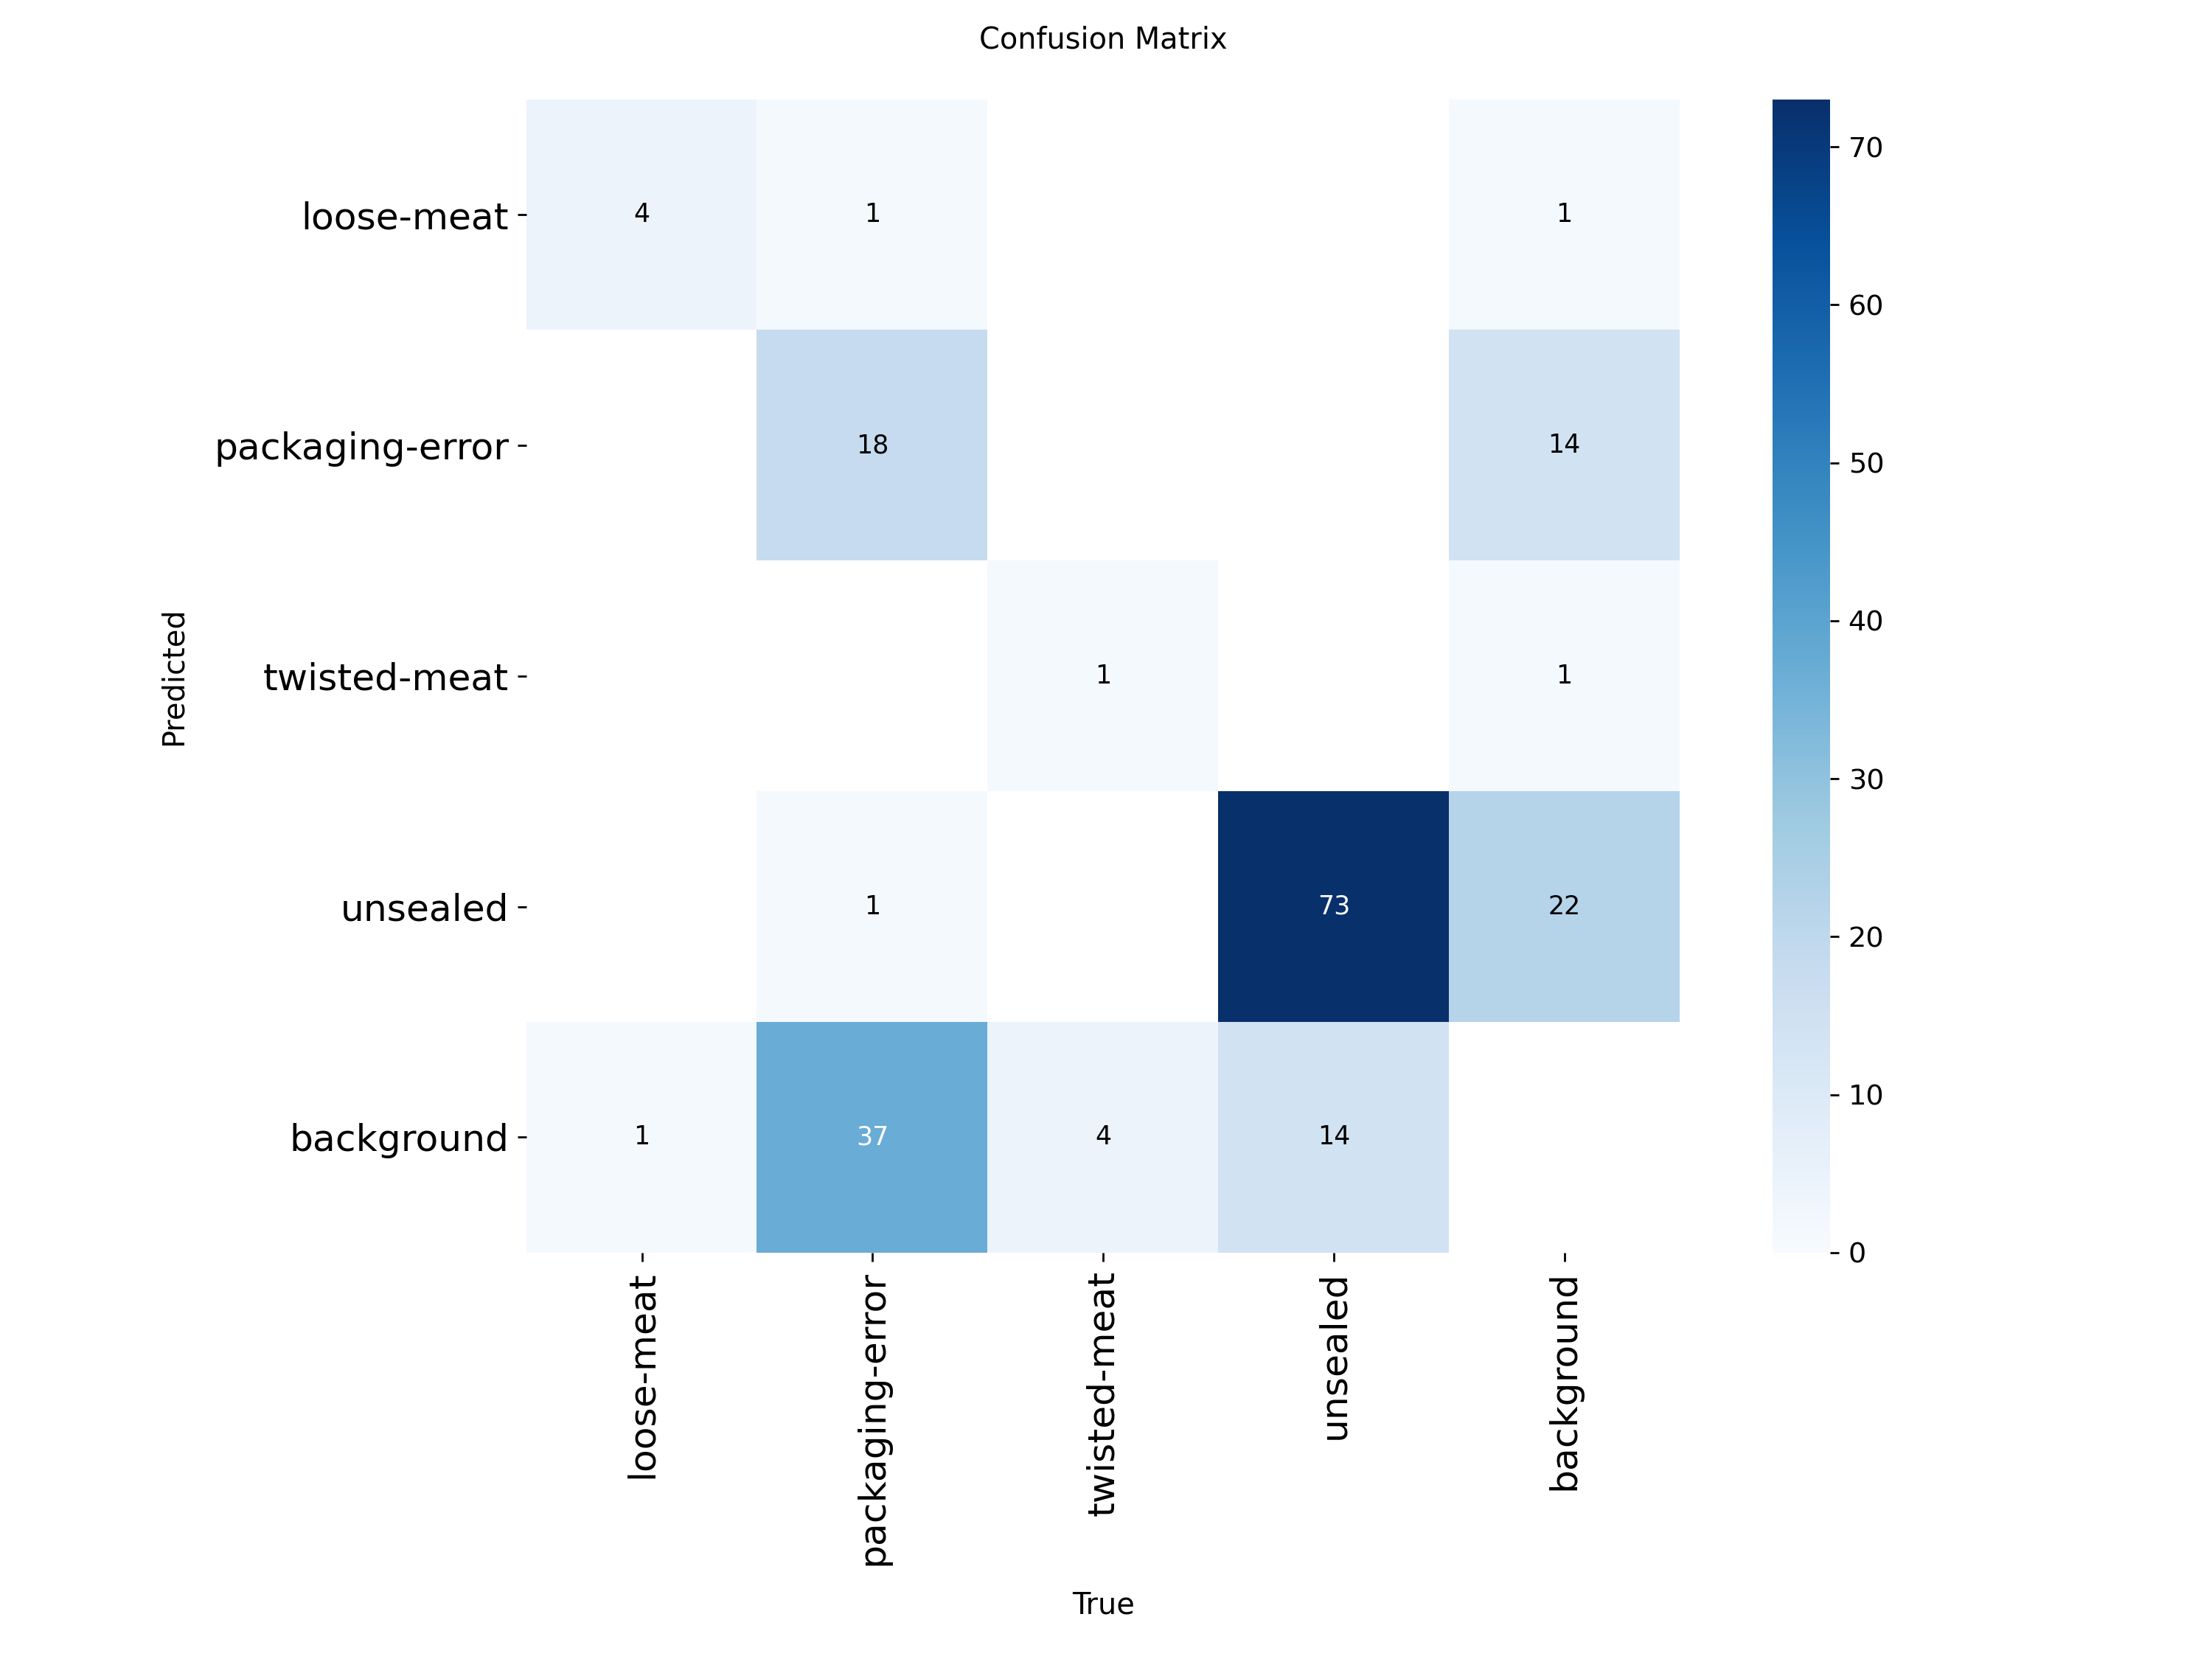

v1_no_mosaic_conf025


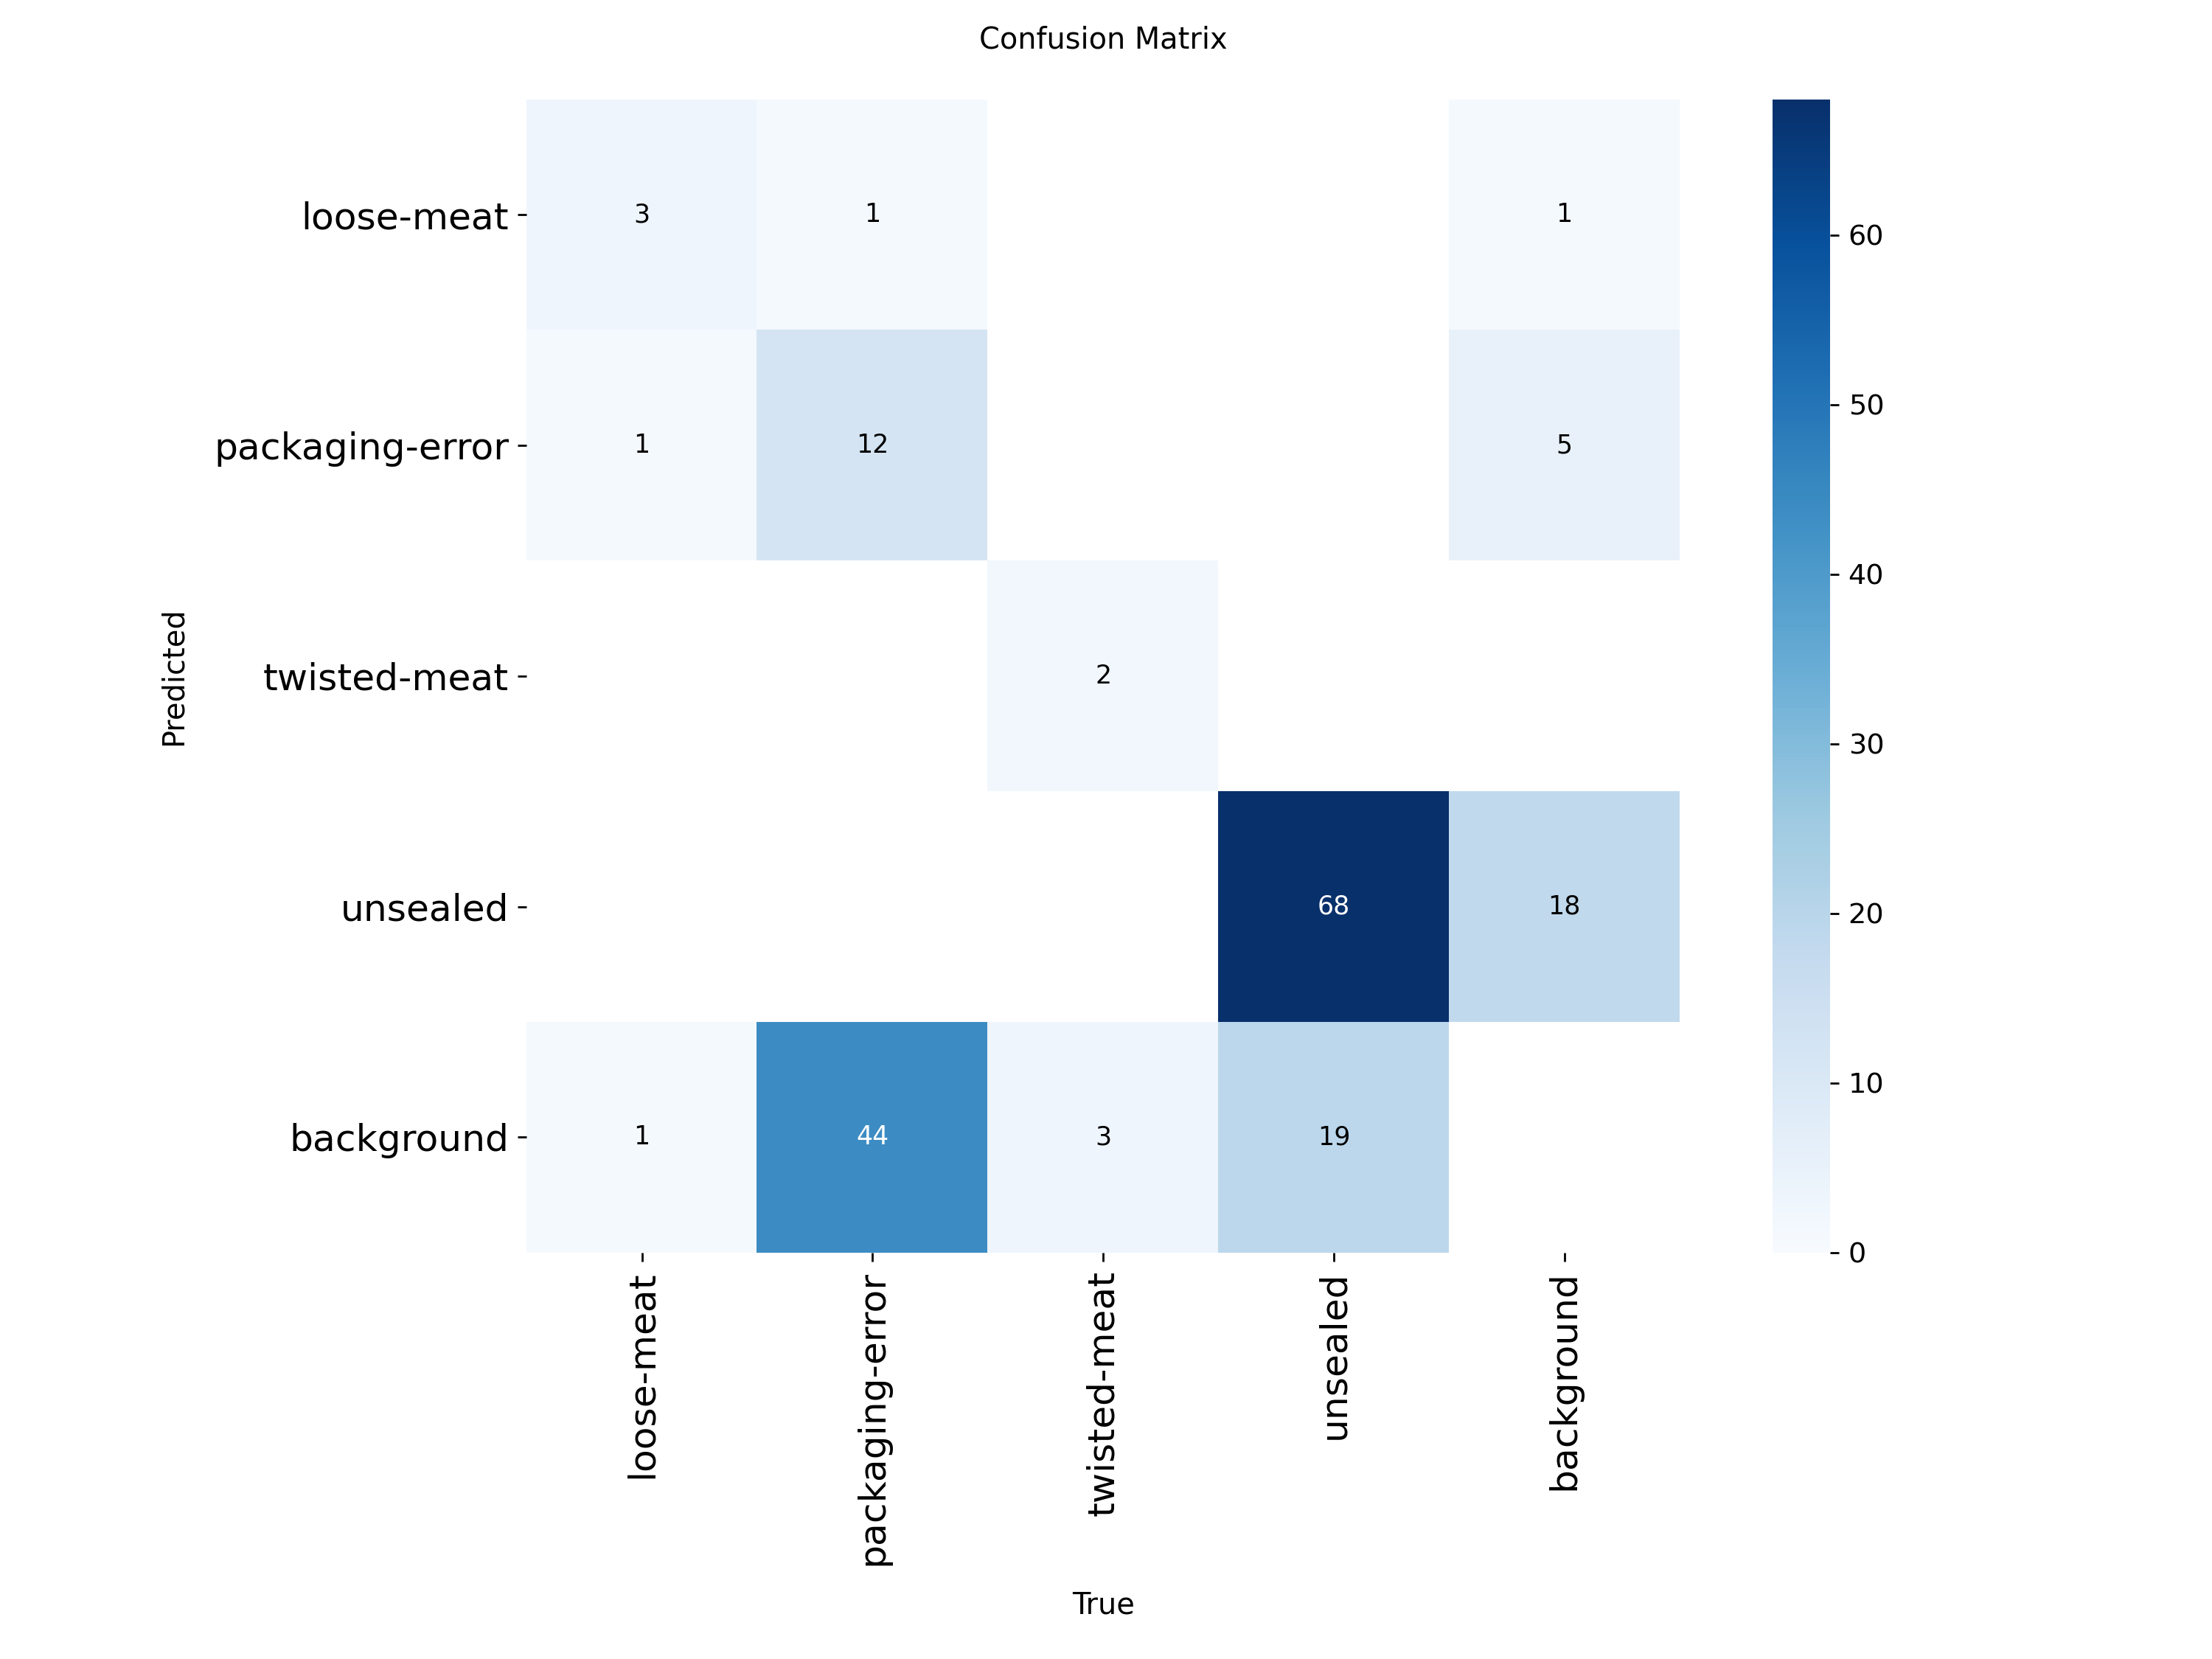

In [12]:
# 11. Compare confusion matrices at confidence 0.25
from PIL import Image

for name in ["v1_baseline_conf025", "v1_no_mosaic_conf025"]:
    print(name)
    display(Image.open(runs / name / "confusion_matrix.png"))

v1_baseline_comparison


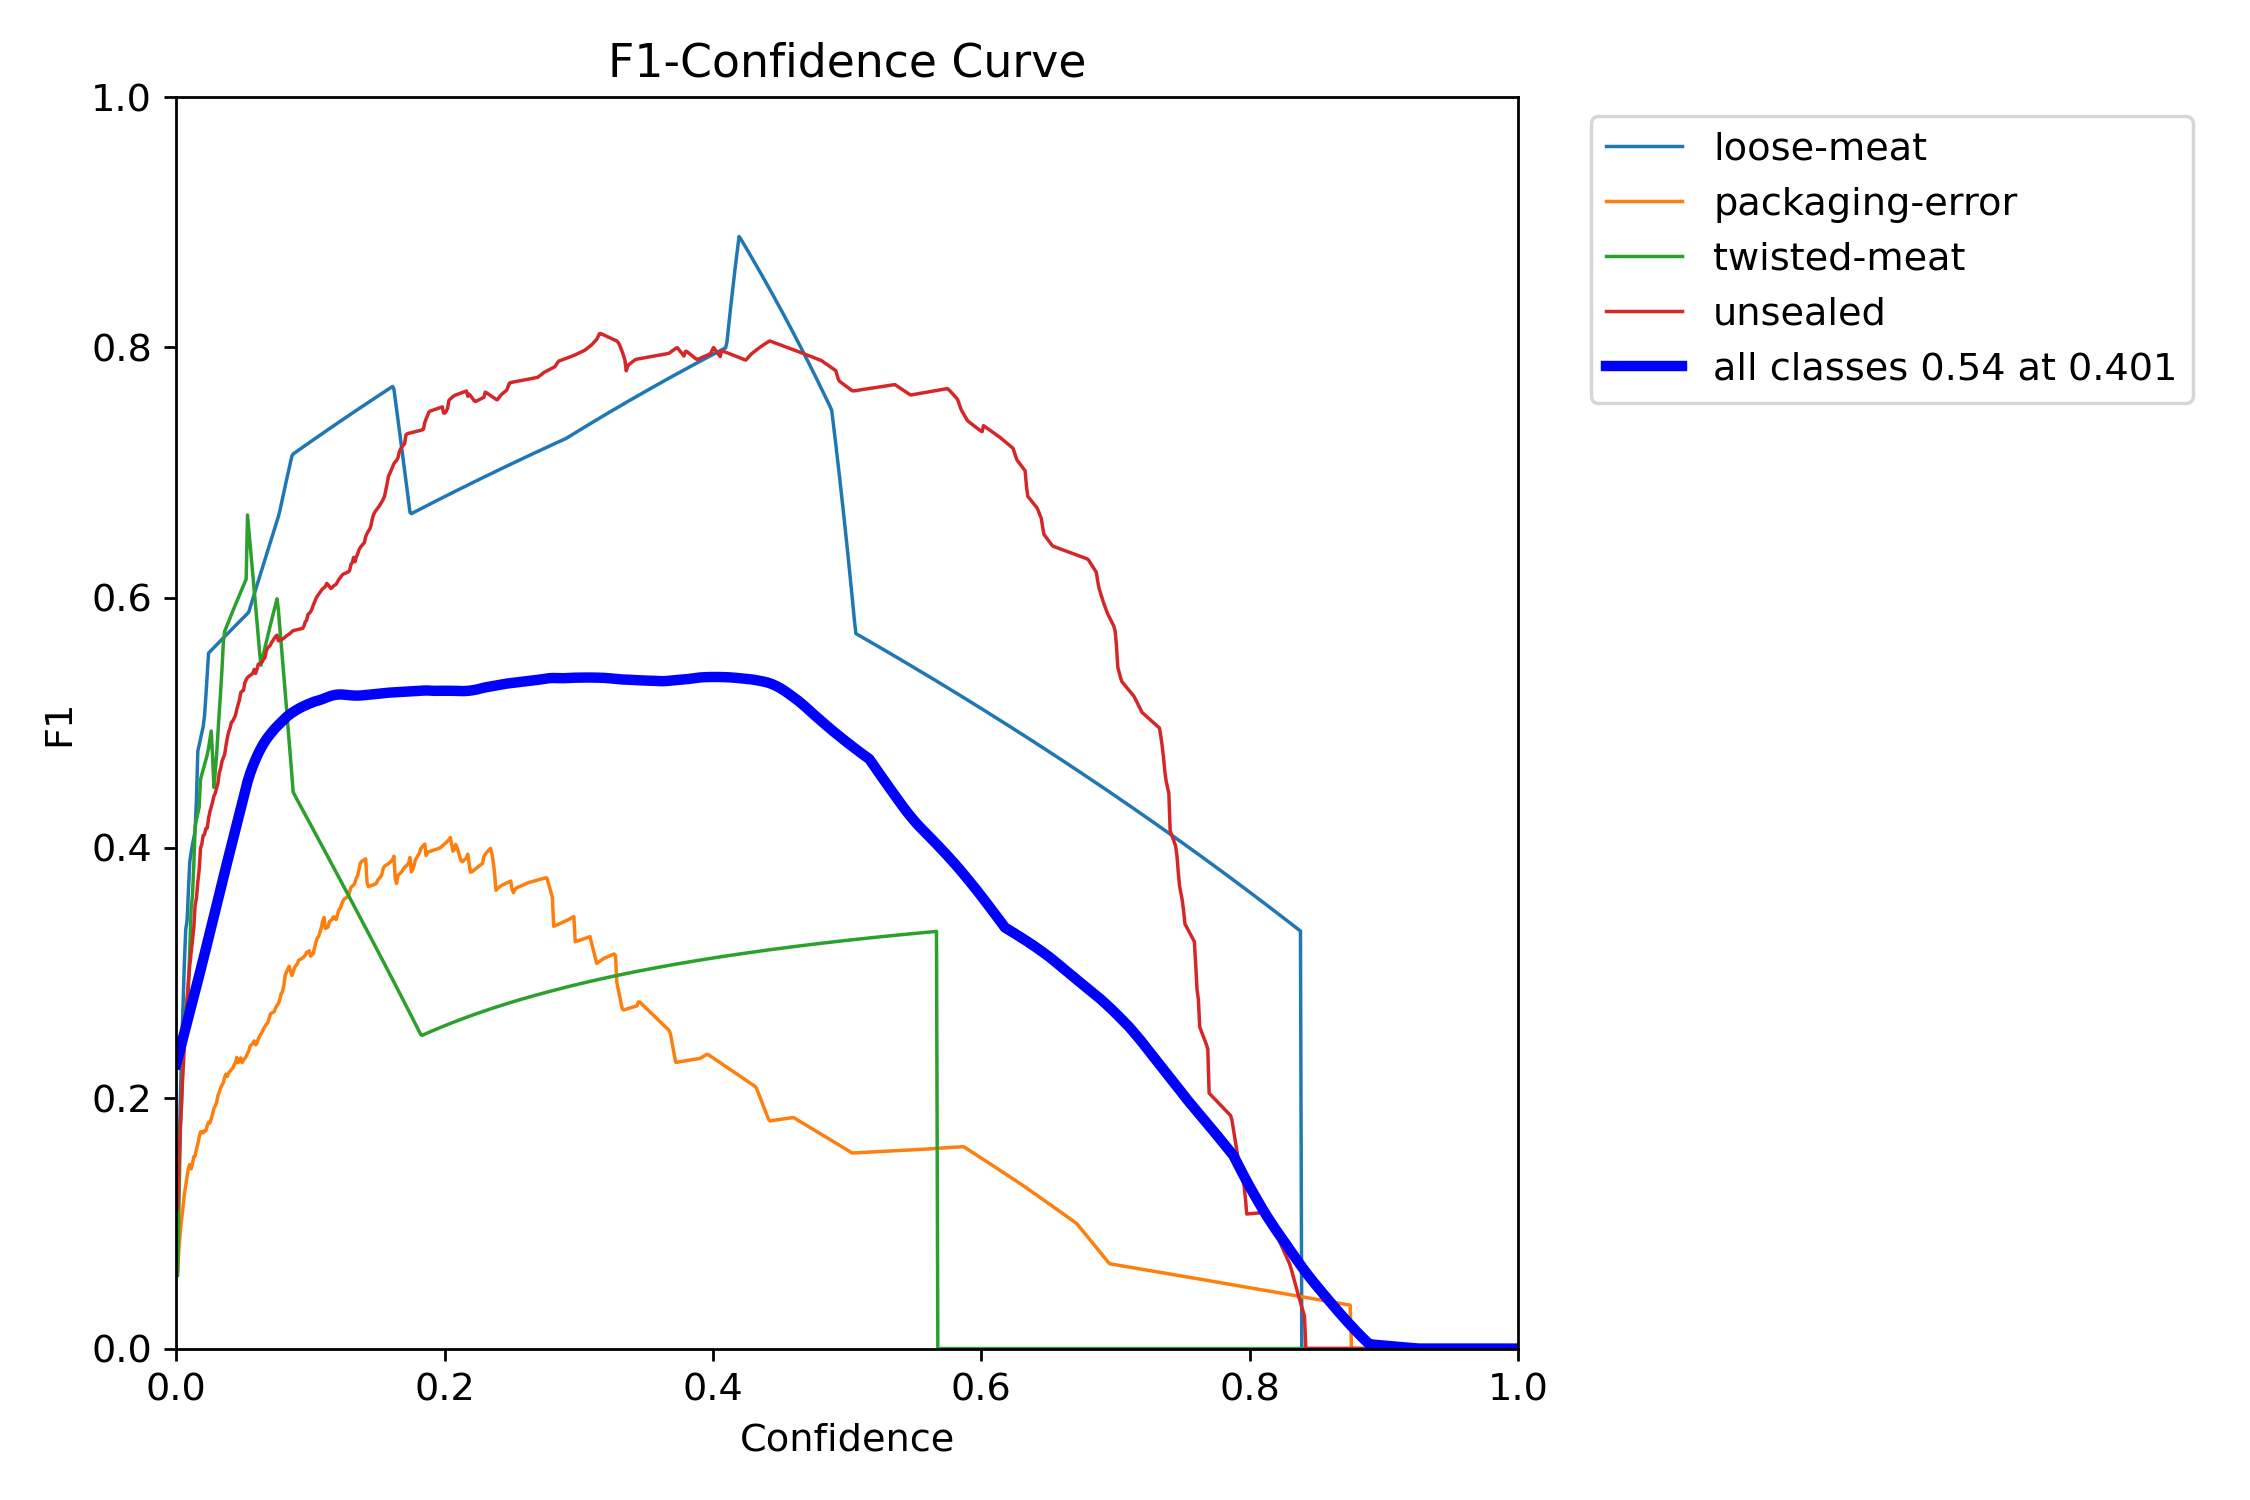

v1_no_mosaic_comparison


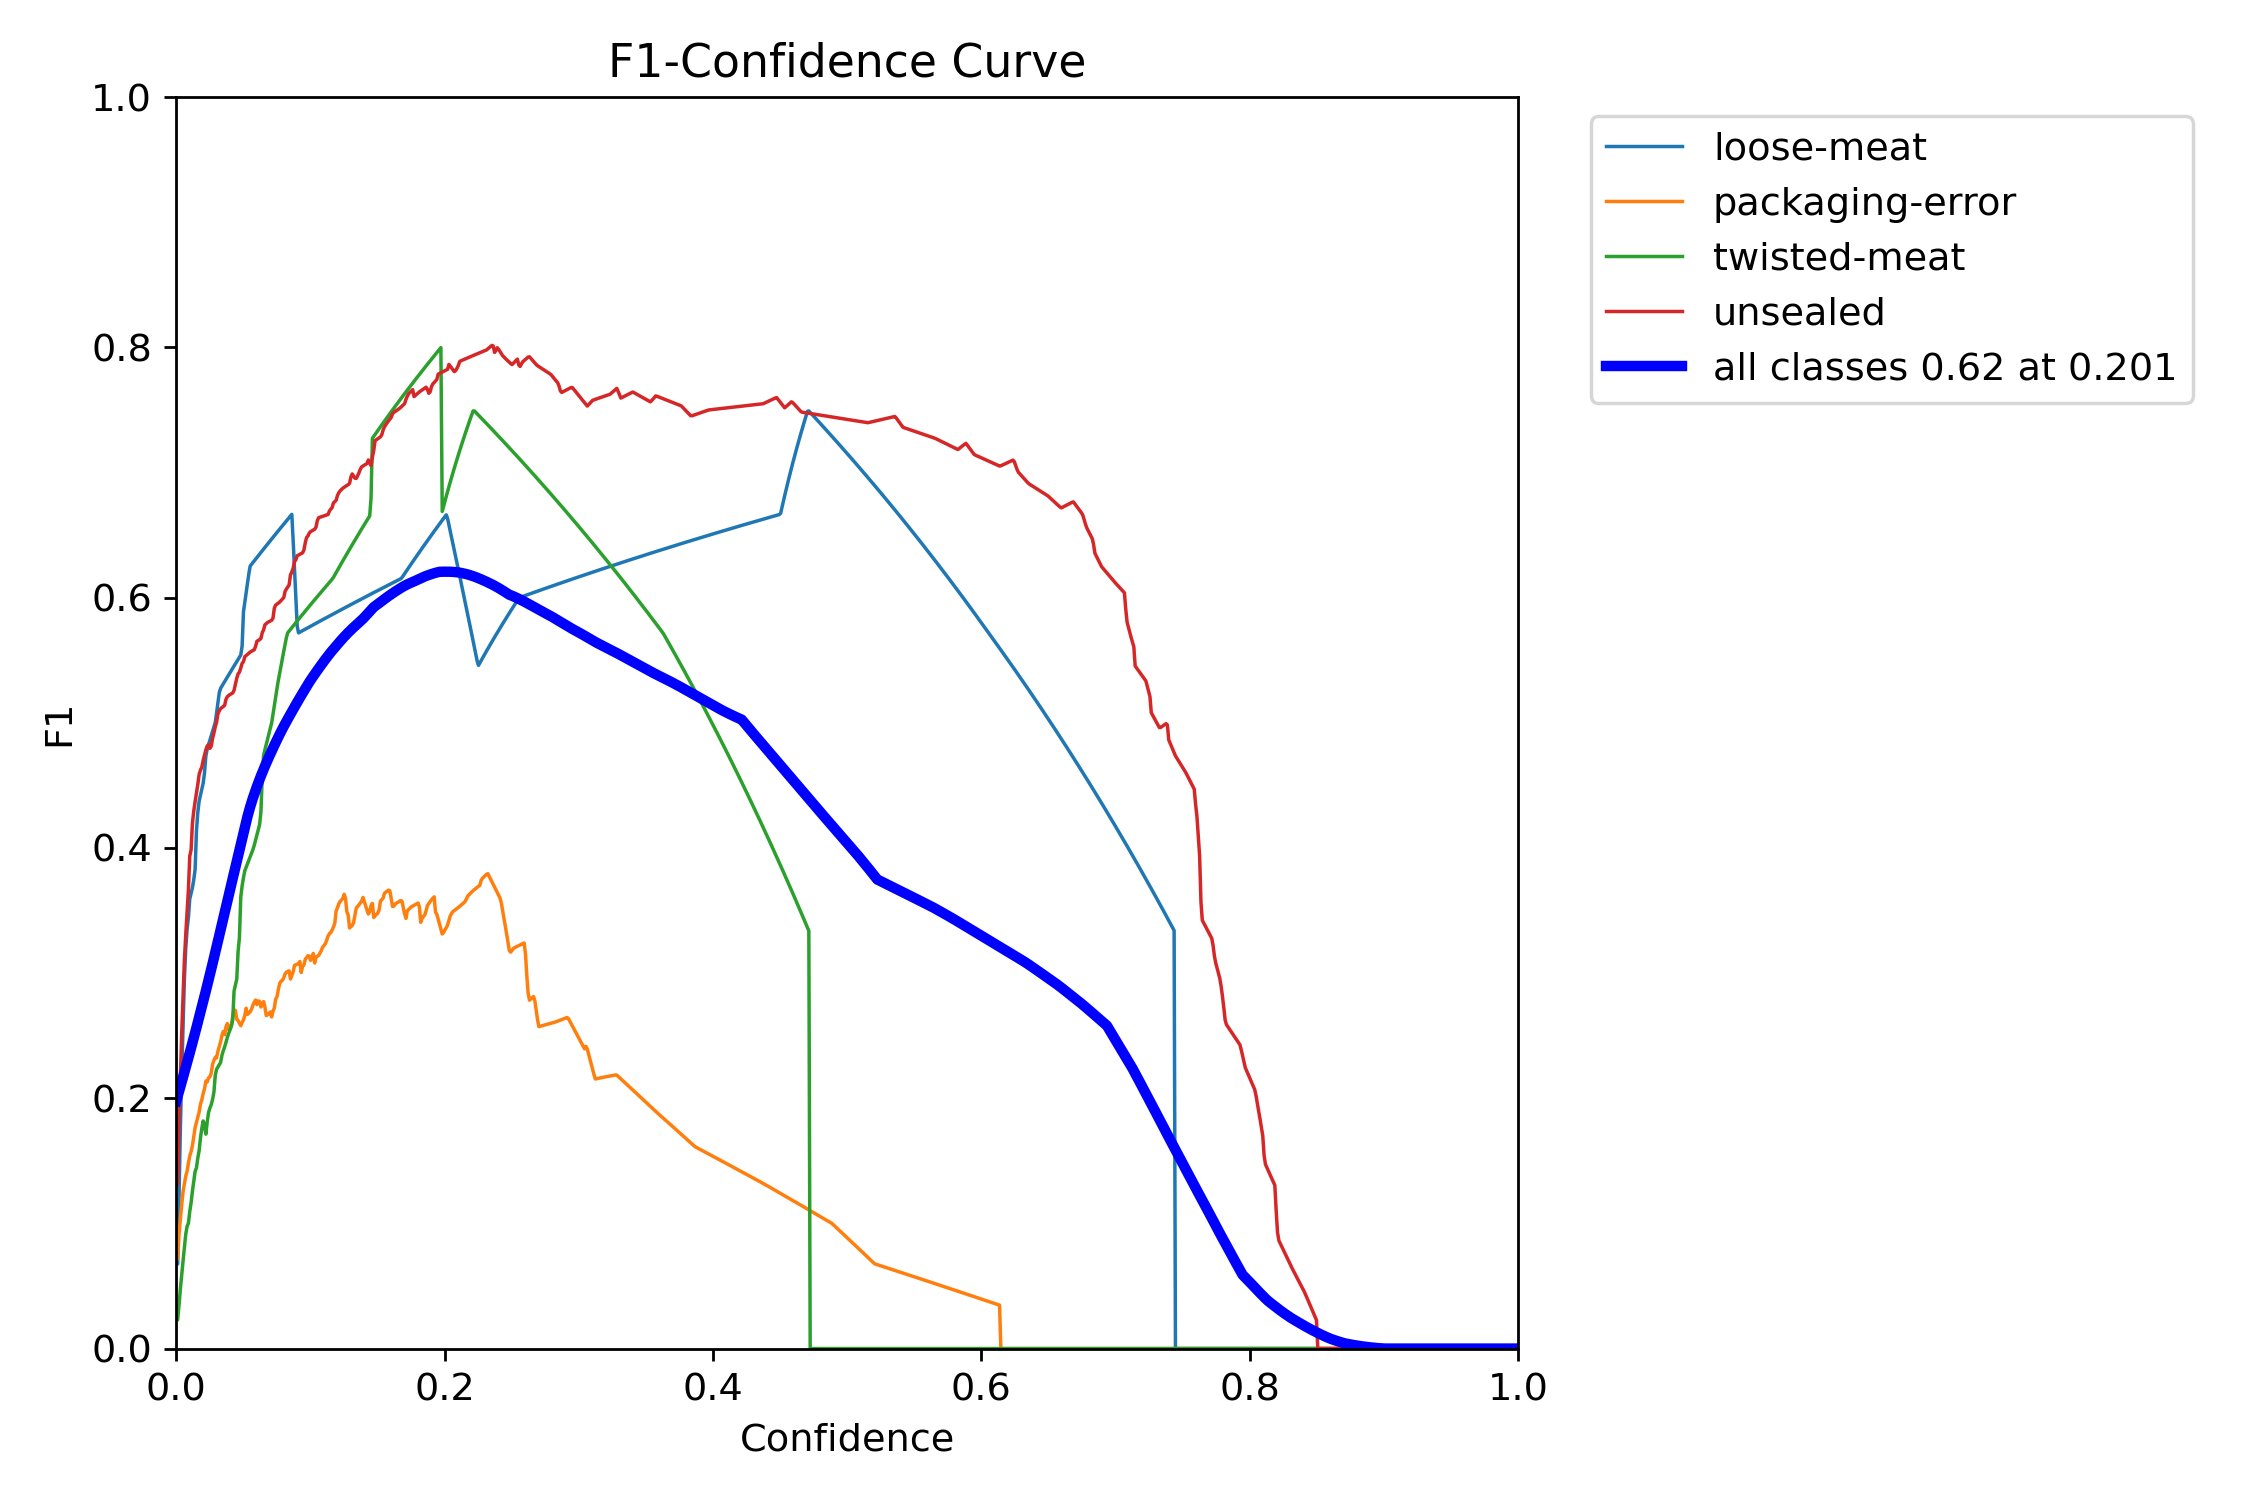

In [13]:
# 12. Compare F1-confidence curves
from PIL import Image

for name in ["v1_baseline_comparison", "v1_no_mosaic_comparison"]:
    print(name)
    display(Image.open(runs / name / "BoxF1_curve.png"))

In [14]:
# 13. Evaluate both models at their peak-F1 confidence
models = {
    "baseline": (baseline, 0.401),
    "no_mosaic": (no_mosaic, 0.201)
}

for name, (model, conf) in models.items():
    print(f"\nEvaluating {name} at confidence {conf}")

    result = model.val(
        data=str(clean / "data.yaml"),
        imgsz=640,
        split="val",
        conf=conf,
        iou=0.7,
        plots=True,
        project=str(runs),
        name=f"v1_{name}_peak_f1",
        exist_ok=True
    )


Evaluating baseline at confidence 0.401
Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 470.7±170.7 MB/s, size: 74.8 KB)
val: Scanning /content/pork_rasher_dataset_v1_clean/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 3.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.2s/it 25.7s
                   all        119        154      0.847      0.462      0.451      0.217
            loose-meat          5          5        0.8        0.8      0.795      0.287
       packaging-error         35         57        0.7      0.123      0.114     0.0503
          twisted-meat          4          5          1        0.2      0.195     0.0975
              unsealed         84         87      0.887      0.724        0.7

v1_baseline_peak_f1


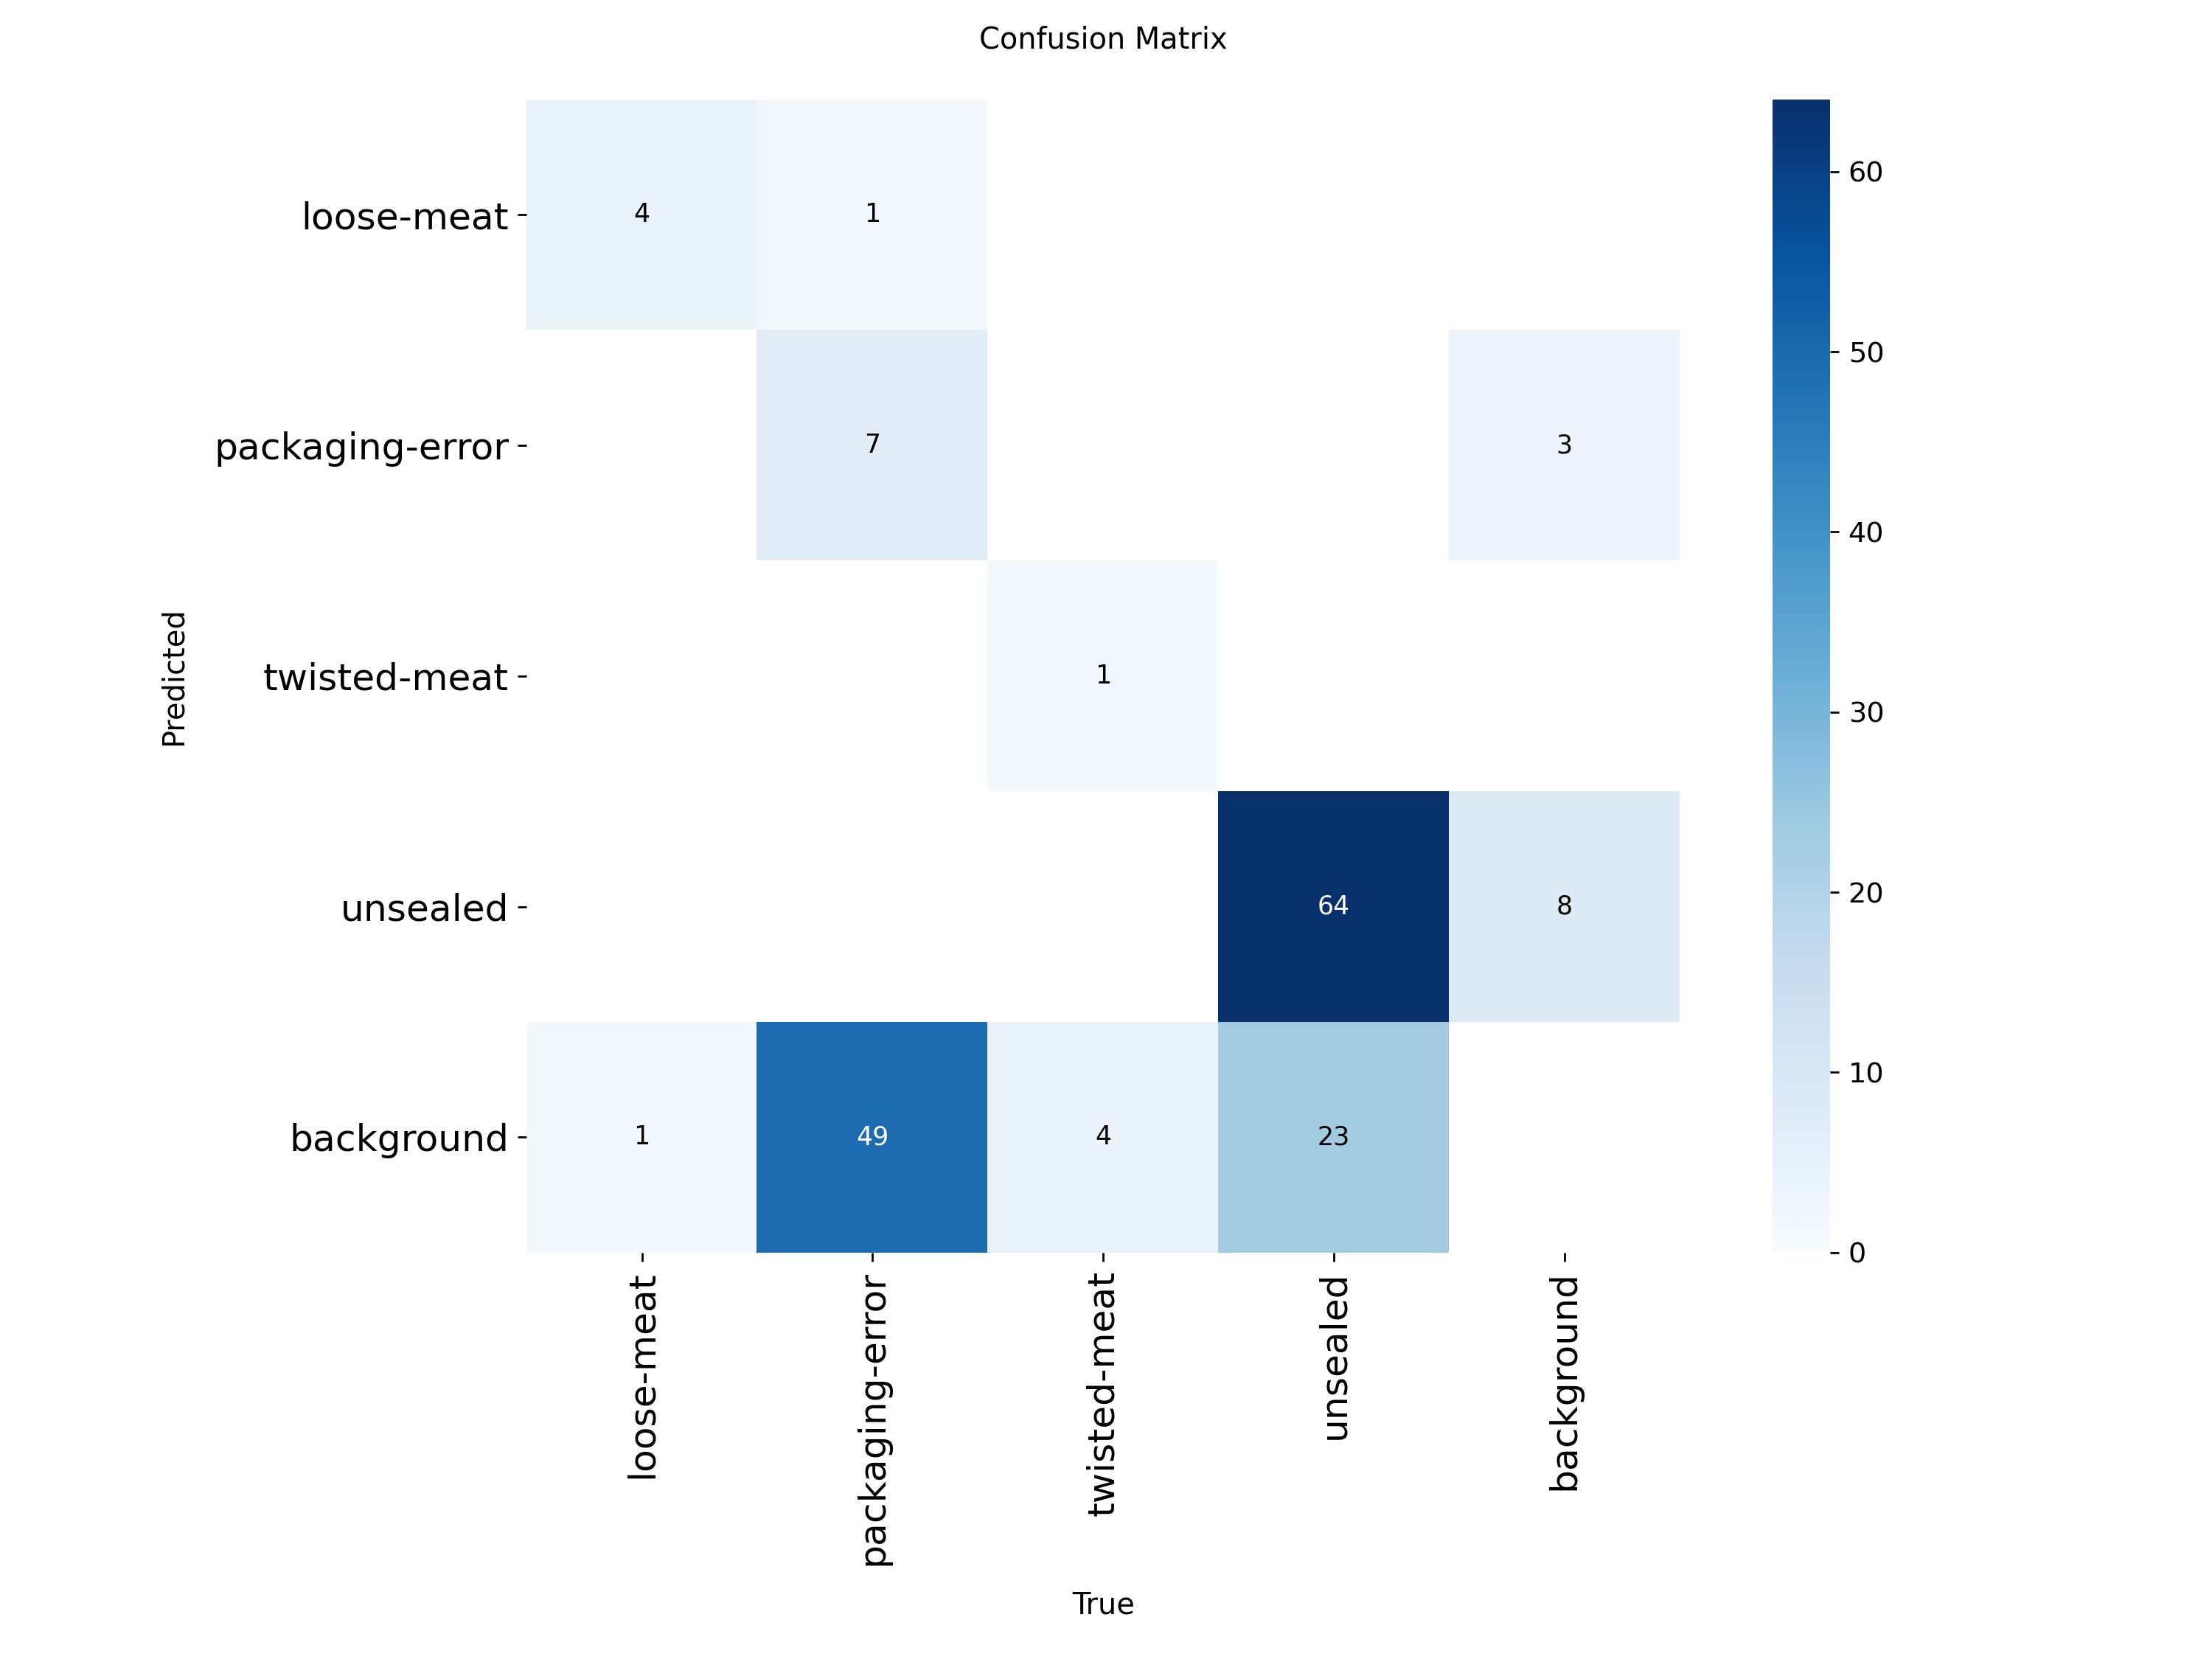

v1_no_mosaic_peak_f1


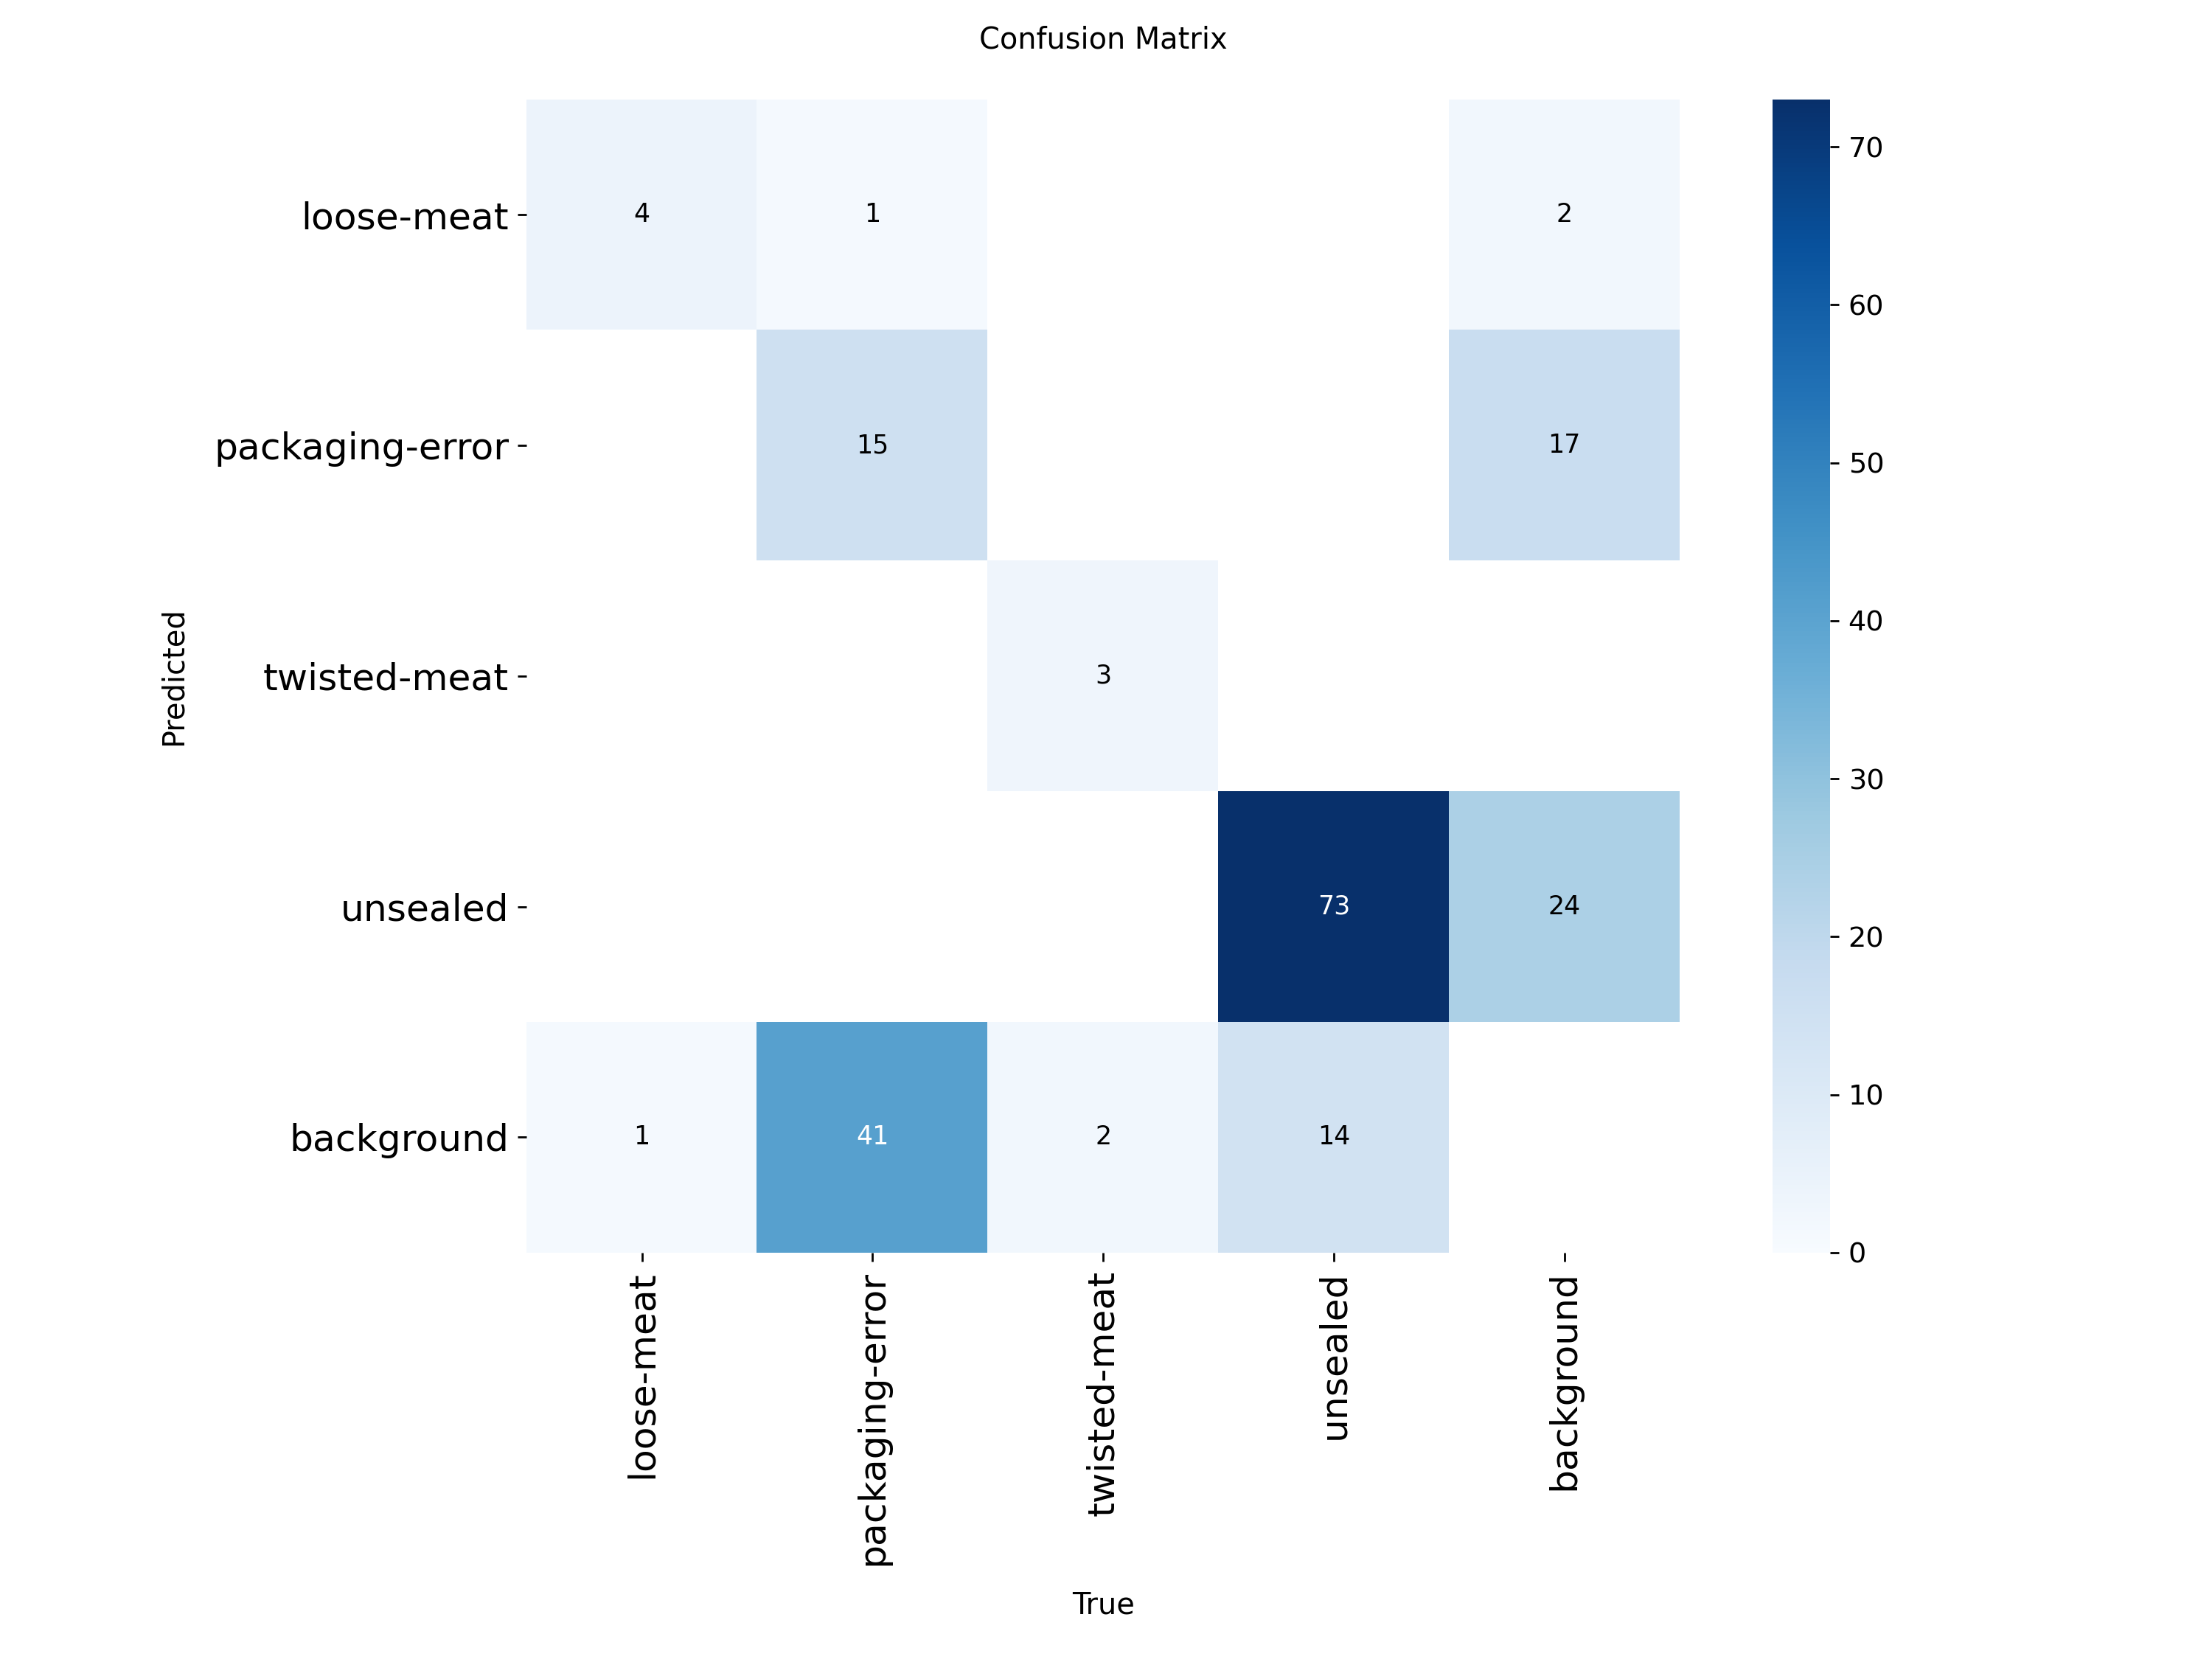

In [15]:
# 14. Compare confusion matrices at peak-F1 confidence
from PIL import Image

for name in ["v1_baseline_peak_f1", "v1_no_mosaic_peak_f1"]:
    print(name)
    display(Image.open(runs / name / "confusion_matrix.png"))

In [16]:
# 15. Find missed packaging-error images
val_images = clean / "valid/images"
val_labels = clean / "valid/labels"

missed_images = []

for label in val_labels.glob("*.txt"):
    classes = [int(line.split()[0]) for line in label.read_text().splitlines()]

    if 1 not in classes:
        continue

    image = val_images / f"{label.stem}.jpg"
    result = no_mosaic.predict(str(image), conf=0.201, verbose=False)[0]

    if 1 not in result.boxes.cls.tolist():
        missed_images.append(image)

print("Images with missed packaging errors:", len(missed_images))
print("First five:", [p.name for p in missed_images[:5]])

Images with missed packaging errors: 18
First five: ['frame_with_red_1782_jpg.rf.3a1f42bb4d251f47bb71c74d16655c5b.jpg', 'frame_with_red_3080_jpg.rf.5c575db554b4c24beb47e9f4745d7d1e.jpg', 'frame_with_red_1456_jpg.rf.dea60a2ee142832fbebe0ed93f1e590b.jpg', 'frame_with_red_4925_jpg.rf.a30a23a16f1499f590da133f4241dcfc.jpg', 'frame_with_red_1195_jpg.rf.e28023cc47fdca6a62d8ef5c84fc4a75.jpg']


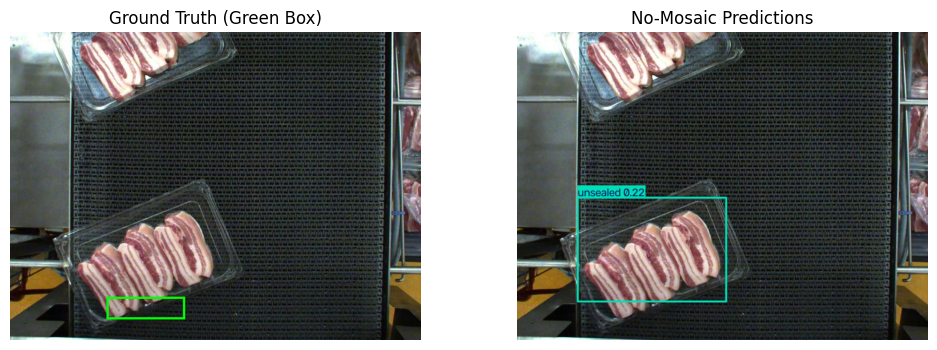

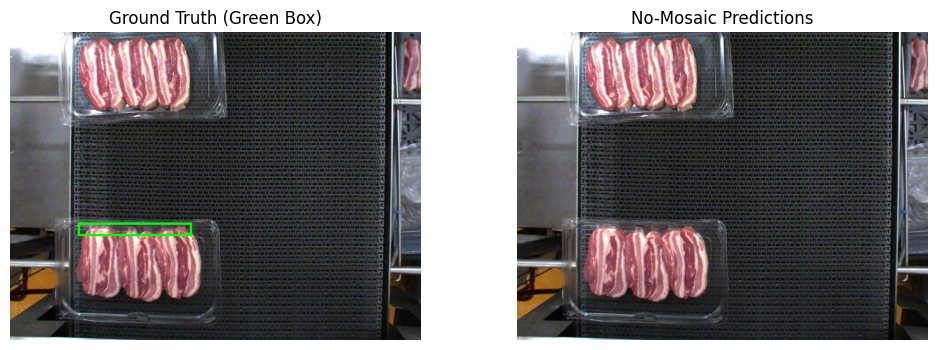

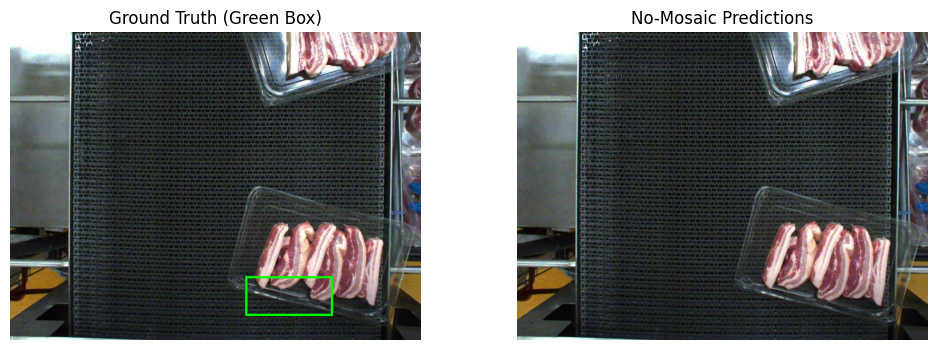

In [17]:
# 16. Compare ground truth with model predictions
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

for image_path in missed_images[:3]:
    image = Image.open(image_path).convert("RGB")
    ground_truth = image.copy()
    draw = ImageDraw.Draw(ground_truth)
    W, H = image.size

    # Draw actual packaging-error boxes
    label = val_labels / f"{image_path.stem}.txt"

    for line in label.read_text().splitlines():
        cls, x, y, w, h = map(float, line.split())

        if int(cls) == 1:
            box = [(x-w/2)*W, (y-h/2)*H, (x+w/2)*W, (y+h/2)*H]
            draw.rectangle(box, outline="lime", width=4)

    # Model predictions
    result = no_mosaic.predict(str(image_path), conf=0.201, imgsz=640, verbose=False)[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(ground_truth)
    axes[0].set_title("Ground Truth (Green Box)")
    axes[1].imshow(result.plot()[:, :, ::-1])
    axes[1].set_title("No-Mosaic Predictions")

    for ax in axes:
        ax.axis("off")

    plt.show()

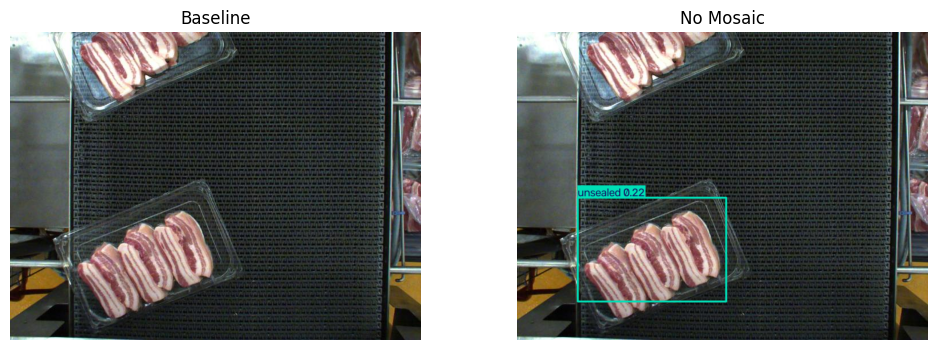

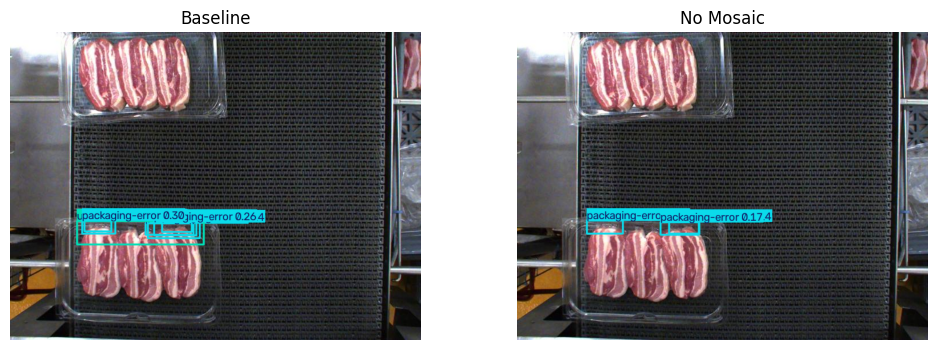

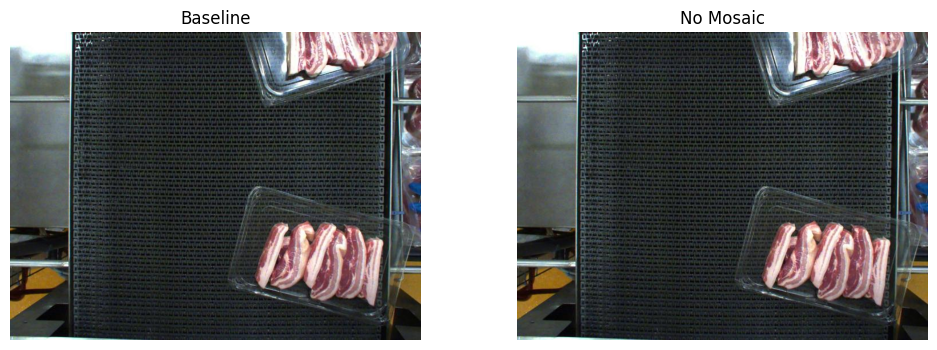

In [18]:
# 17. Compare baseline and no-mosaic predictions
for image_path in missed_images[:3]:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, (name, model) in zip(axes, [
        ("Baseline", baseline),
        ("No Mosaic", no_mosaic)
    ]):
        result = model.predict(
            str(image_path),
            imgsz=640,
            conf=0.10,
            verbose=False
        )[0]

        ax.imshow(result.plot()[:, :, ::-1])
        ax.set_title(name)
        ax.axis("off")

    plt.show()

In [8]:
# 18. Train V1 without mosaic at higher resolution
%pip install -q ultralytics
from ultralytics import YOLO

model_960 = YOLO("yolov8n.pt")

results_960 = model_960.train(
    data=str(clean / "data.yaml"),
    epochs=30,
    imgsz=960,
    batch=16,
    device=0,
    seed=42,
    mosaic=0.0,
    project=str(runs),
    name="yolov8n_v1_no_mosaic_960"
)

print("Training results saved to:", results_960.save_dir)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pork_rasher_dataset_v1_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolov8n_v1_no_mosaic_960, nb

In [9]:
# 20. Evaluate existing 640 model at 960 resolution
model_640 = YOLO(str(runs / "yolov8n_v1_no_mosaic/weights/best.pt"))

results_640_at960 = model_640.val(
    data=str(clean / "data.yaml"),
    imgsz=960,
    split="val",
    conf=0.001,
    iou=0.7,
    plots=False,
    project=str(runs),
    name="v1_no_mosaic_640_at960",
    exist_ok=True
)

print("Comparison complete!")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2340.5±583.5 MB/s, size: 74.2 KB)
val: Scanning /content/pork_rasher_dataset_v1_clean/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 35.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.0it/s 2.6s
                   all        119        154      0.617      0.553      0.577       0.23
            loose-meat          5          5      0.682        0.8      0.814      0.217
       packaging-error         35         57      0.454      0.211      0.253       0.08
          twisted-meat          4          5      0.547      0.494      0.467      0.165
              unsealed         84         87      0.783      0.706      0.776      0.459
Speed: 3.7ms preprocess, 8.1m

In [10]:
# 21. Evaluate selected V1 model on test dataset

test_results = model_640.val(
    data=str(clean / "data.yaml"),
    imgsz=640,
    split="test",
    conf=0.001,
    iou=0.7,
    plots=True,
    project=str(runs),
    name="v1_selected_final_test",
    exist_ok=True
)

print("Test evaluation complete!")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2164.7±810.1 MB/s, size: 73.4 KB)
val: Scanning /content/pork_rasher_dataset_v1_clean/test/labels... 80 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 2.1Kit/s 0.0s
val: New cache created: /content/pork_rasher_dataset_v1_clean/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.0it/s 5.0s
                   all         80         99      0.528      0.524      0.544      0.226
            loose-meat          2          3      0.685      0.667      0.775      0.189
       packaging-error         26         37      0.435      0.459      0.376      0.106
          twisted-meat          7          7      0.351      0.239      0.341      0.193
              unsealed         51         52     

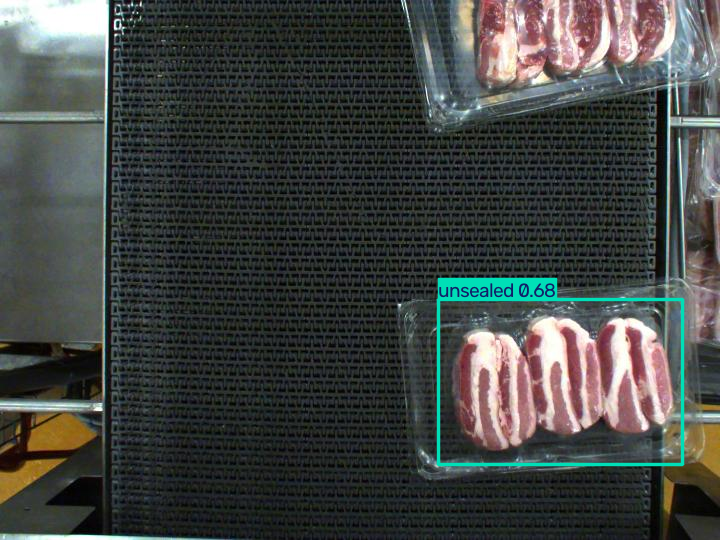

In [11]:
# 22. Demonstrate selected model on a test image
from PIL import Image

image_path = next((clean / "test/images").glob("*.jpg"))

result = model_640.predict(
    source=str(image_path),
    imgsz=640,
    conf=0.201,
    verbose=False
)[0]

display(Image.fromarray(result.plot()[:, :, ::-1]))

In [12]:
# 23. Create a reusable meat-packaging inspection function
def inspect_package(image_path, confidence=0.201):
    """Detect packaging defects in an image."""

    result = model_640.predict(
        source=str(image_path),
        imgsz=640,
        conf=confidence,
        verbose=False
    )[0]

    detections = []

    for box in result.boxes:
        detections.append({
            "defect": result.names[int(box.cls.item())],
            "confidence": round(box.conf.item(), 3),
            "box": box.xyxy[0].tolist()
        })

    return detections

# Test the function
detections = inspect_package(image_path)

print("Detected defects:")
for detection in detections:
    print(detection)

Detected defects:
{'defect': 'unsealed', 'confidence': 0.679, 'box': [438.5738830566406, 299.5414123535156, 682.9223022460938, 464.5154724121094]}


In [13]:
# 24. Test inspection function
def test_inspection():
    detections = inspect_package(image_path)

    for detection in detections:
        assert detection["defect"] in model_640.names.values()
        assert 0 <= detection["confidence"] <= 1

        x1, y1, x2, y2 = detection["box"]
        assert x1 < x2 and y1 < y2

    print("Inspection function test passed!")

test_inspection()

Inspection function test passed!
